In [1]:
!pip install PyWavelets
!pip install albumentations
!pip install grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageEnhance
import cv2
import pywt
from scipy.ndimage import median_filter
import timm
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import random
import shutil
import albumentations as A

In [3]:

seed = 42

np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from PIL import Image
import glob
from multiprocessing import Pool

INPUT_DIR = "/content/drive/MyDrive/rice_disease_images (2560)"
OUTPUT_DIR = "/content/RiceLeaf-Dataset"
TARGET_QUALITY = 90
RESIZE_DIM = (224, 224)

def process_image(img_path):
    """Optimize single image with size and quality adjustments"""
    try:
        with Image.open(img_path) as img:
            relative_path = os.path.relpath(img_path, INPUT_DIR)
            output_path = os.path.join(OUTPUT_DIR, relative_path)
            os.makedirs(os.path.dirname(output_path), exist_ok=True)

            img.thumbnail(RESIZE_DIM, Image.Resampling.LANCZOS)

            if img.mode != 'RGB':
                img = img.convert('RGB')

            img.save(output_path,
                    "JPEG",
                    quality=TARGET_QUALITY,
                    optimize=True,
                    progressive=True,
                    subsampling=0,
                    qtables="web_high"
                    )


            fs = os.path.getsize(output_path) / 1024
            if fs > 150:
                print(f"Warning: {output_path} is {fs:.1f}KB - consider lowering quality")

    except Exception as e:
        print(f"Error processing {img_path}: {str(e)}")

if __name__ == "__main__":

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    image_paths = glob.glob(os.path.join(INPUT_DIR, "**", "*.jpg"), recursive=True) + \
                 glob.glob(os.path.join(INPUT_DIR, "**", "*.jpeg"), recursive=True)


    with Pool(processes=os.cpu_count()) as pool:
        pool.map(process_image, image_paths)

    print(f"Processed {len(image_paths)} images. Output directory: {OUTPUT_DIR}")

Processed 2560 images. Output directory: /content/RiceLeaf-Dataset


In [8]:
print("Splitting into Train/Validation/Test...")


train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15


original_root = '/content/RiceLeaf-Dataset'
split_root = '/content/rice-leaf-disease-dataset'
for split in ['train', 'val', 'test']:
    for category in os.listdir(original_root):
        os.makedirs(os.path.join(split_root, split, category), exist_ok=True)


for category in os.listdir(original_root):
    images = os.listdir(os.path.join(original_root, category))
    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_files = images[:train_end]
    val_files = images[train_end:val_end]
    test_files = images[val_end:]

    for file in train_files:
        src = os.path.join(original_root, category, file)
        dst = os.path.join(split_root, 'train', category, file)
        shutil.copy(src, dst)

    for file in val_files:
        src = os.path.join(original_root, category, file)
        dst = os.path.join(split_root, 'val', category, file)
        shutil.copy(src, dst)

    for file in test_files:
        src = os.path.join(original_root, category, file)
        dst = os.path.join(split_root, 'test', category, file)
        shutil.copy(src, dst)

print("🎯 Dataset Splited into Train/Val/Test folders!")




train_root = '/content/rice-leaf-disease-dataset/train'
augmented_root = '/content/augmented_train'


transform = A.Compose([
    A.RandomRotate90(),
    A.HorizontalFlip(p=0.5),
    A.Transpose(),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30),
    ], p=0.5),
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, border_mode=cv2.BORDER_REFLECT_101),
        A.GridDistortion(border_mode=cv2.BORDER_REFLECT_101),
        A.OpticalDistortion(distort_limit=1.0, border_mode=cv2.BORDER_REFLECT_101),
    ], p=0.5),
    A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), p=0.5)
])

os.makedirs(augmented_root, exist_ok=True)

for category in os.listdir(train_root):
    category_path = os.path.join(train_root, category)
    save_path = os.path.join(augmented_root, category)
    os.makedirs(save_path, exist_ok=True)

    images = os.listdir(category_path)

    for img_name in images:
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path)
        cv2.imwrite(os.path.join(save_path, img_name), img)

    total_needed = 650
    already_have = len(images)
    augment_per_image = (total_needed - already_have) // already_have + 1

    for img_name in tqdm(images, desc=f"Augmenting {category}"):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path)
        for i in range(augment_per_image):
            augmented = transform(image=img)["image"]
            aug_img_name = f"{img_name.split('.')[0]}_aug_{i}.jpg"
            cv2.imwrite(os.path.join(save_path, aug_img_name), augmented)


    final_images = os.listdir(save_path)
    if len(final_images) > total_needed:
        extra = len(final_images) - total_needed
        random.shuffle(final_images)
        for img_name in final_images[:extra]:
            os.remove(os.path.join(save_path, img_name))

print("\n✅ Done! All classes now have exactly 650 images for training.")

Splitting into Train/Validation/Test...
🎯 Dataset Splited into Train/Val/Test folders!


Augmenting Brown Spot: 100%|██████████| 251/251 [00:01<00:00, 153.40it/s]


✅ Done! All classes now have exactly 650 images for training.


In [9]:
class RiceLeafDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for label, category in enumerate(['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight']):
            folder_path = os.path.join(root_dir, category)
            for img_name in os.listdir(folder_path):
                self.image_paths.append(os.path.join(folder_path, img_name))
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]


        image = Image.open(image_path).convert('RGB')


        if self.transform:
            image = self.transform(image)

        return image, label

class RemapColors:
    def __init__(self, target_mean=128, stretch=True, percentile_stretch=True):
        self.target_mean = target_mean
        self.stretch = stretch
        self.percentile_stretch = percentile_stretch

    def __call__(self, img):

        img = np.array(img).astype(np.float32)


        mask = np.any(img > 10, axis=-1)
        valid_pixels = img[mask]


        adjusted_img = img.copy()

        if valid_pixels.size > 0:
            for i in range(3):
                if self.stretch:

                    if self.percentile_stretch:
                        min_val = np.percentile(valid_pixels[:, i], 1)
                        max_val = np.percentile(valid_pixels[:, i], 99)
                    else:
                        min_val, max_val = valid_pixels[:, i].min(), valid_pixels[:, i].max()

                    if max_val - min_val > 1e-5:
                        adjusted_img[:, :, i] = (img[:, :, i] - min_val) / (max_val - min_val) * 255
                    else:
                        adjusted_img[:, :, i] = img[:, :, i]
                else:

                    mean_color = valid_pixels.mean(axis=0)
                    adjusted_img[:, :, i] = img[:, :, i] - mean_color[i] + self.target_mean


                adjusted_img[~mask, i] = 0


        adjusted_img = np.clip(adjusted_img, 0, 255).astype(np.uint8)
        return Image.fromarray(adjusted_img)


transform = transforms.Compose([
    RemapColors(target_mean=128, stretch=True),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(1),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(contrast=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


dataset = RiceLeafDataset(root_dir="/content/augmented_train", transform=transform)
dataloader = DataLoader(dataset, batch_size=40, shuffle=True)

images, labels = next(iter(dataloader))
print(images.shape, labels.shape)

torch.Size([40, 3, 224, 224]) torch.Size([40])


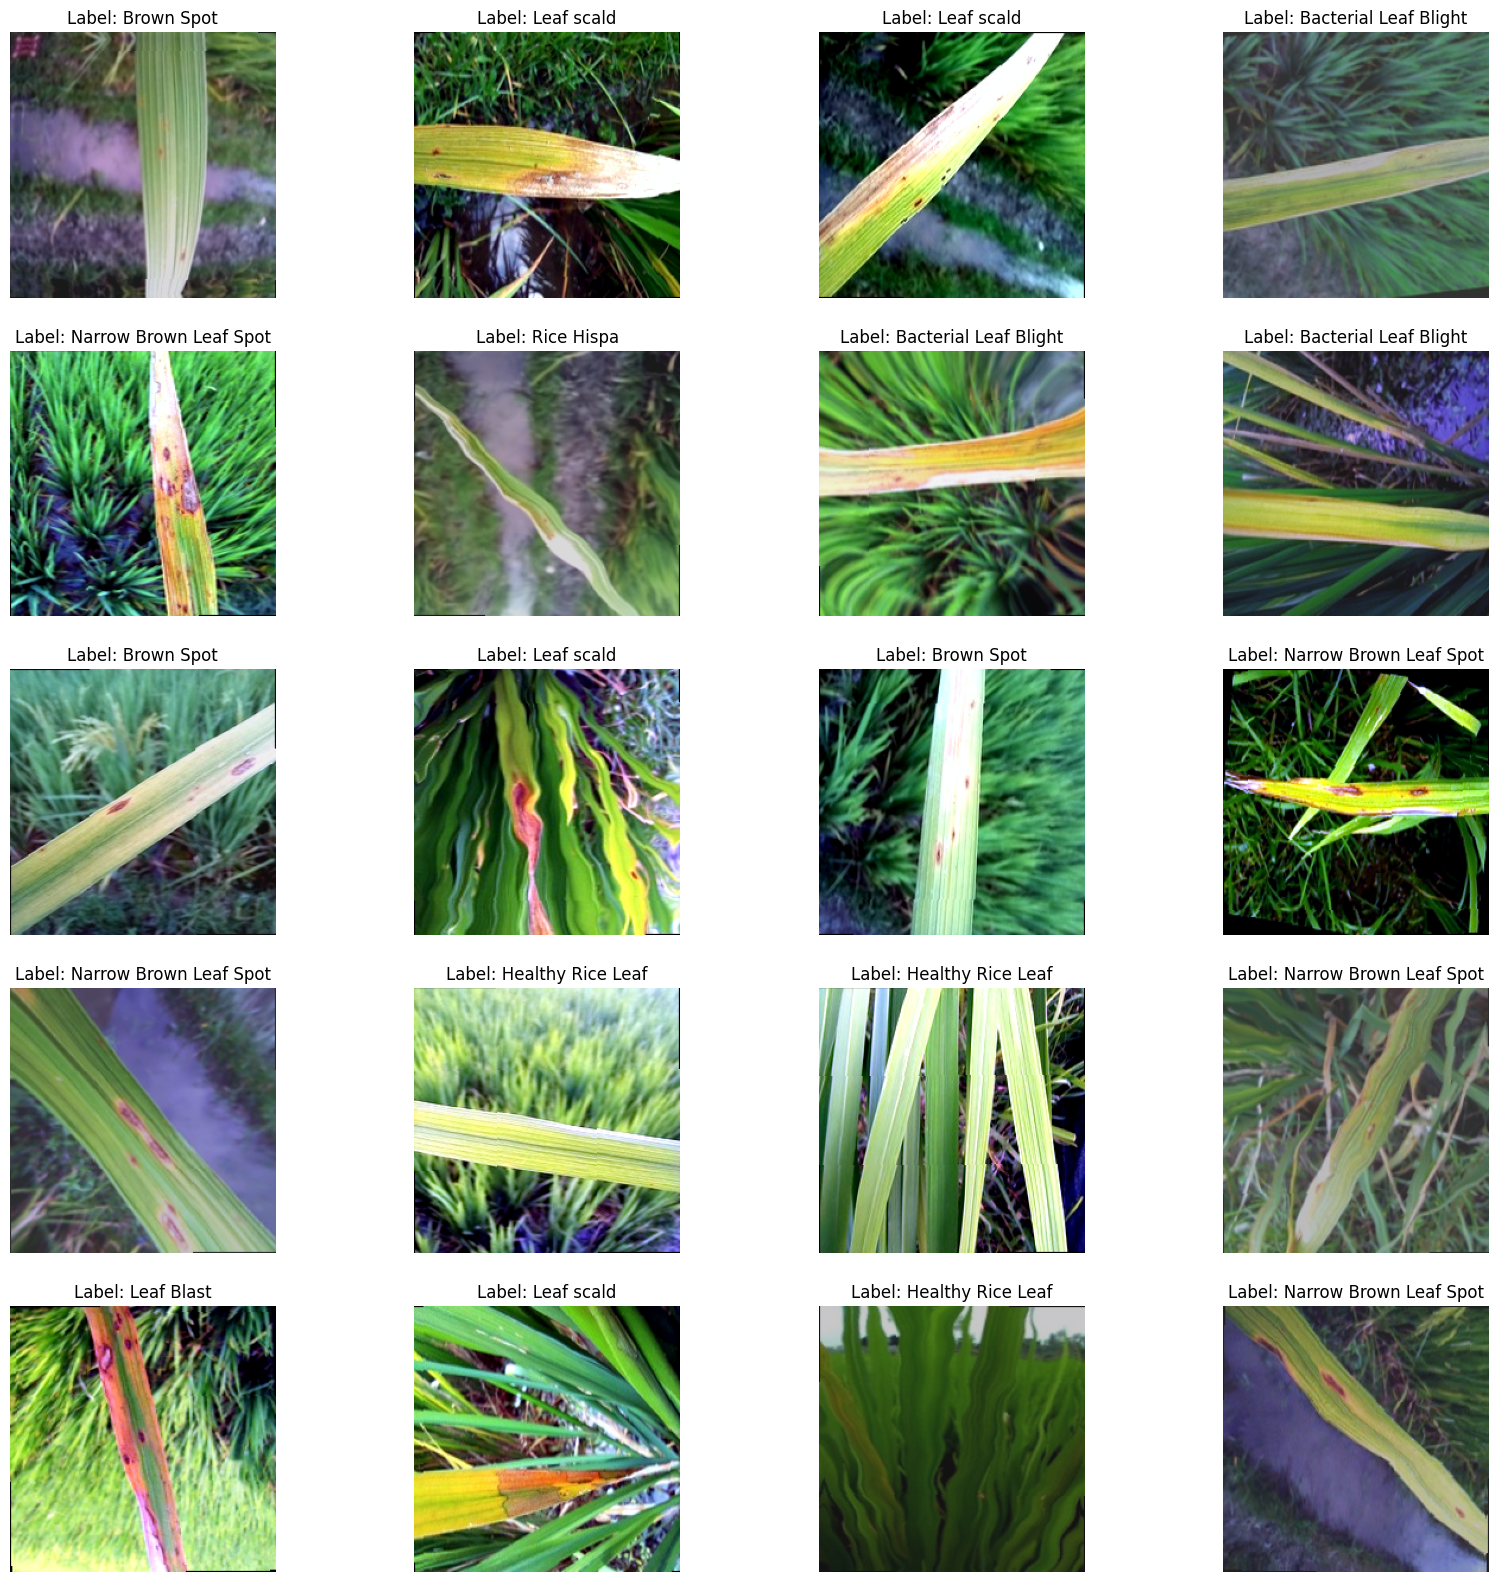

In [10]:
images, labels = next(iter(dataloader))

def imshow(img, title):
    img = img.permute(1, 2, 0).numpy()
    imagenet_mean = np.array([0.485, 0.456, 0.406])
    imagenet_std = np.array([0.229, 0.224, 0.225])
    img = img * imagenet_std + imagenet_mean

    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

label_names = ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight']
plt.figure(figsize=(20, 20))
for i in range(20):
    plt.subplot(5, 4, i + 1)
    imshow(images[i], f"Label: {label_names[labels[i]]}")

plt.show()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s]



Epoch 1/25


100%|██████████| 12/12 [00:03<00:00,  3.27it/s]


Train Loss: 1.0551, Train Acc: 0.6967
Val Loss: 2.0184, Val Acc: 0.2526

Epoch 2/25


...

Train Loss: 0.2719, Train Acc: 0.9998
Val Loss: 0.4009, Val Acc: 0.9531

Epoch 24/25


100%|██████████| 12/12 [00:03<00:00,  3.44it/s]


Train Loss: 0.2717, Train Acc: 1.0000
Val Loss: 0.4011, Val Acc: 0.9531

Epoch 25/25


100%|██████████| 12/12 [00:04<00:00,  2.95it/s]


Train Loss: 0.2722, Train Acc: 1.0000
Val Loss: 0.4015, Val Acc: 0.9505
Best Validation Accuracy (EMA+TTA): 0.9531


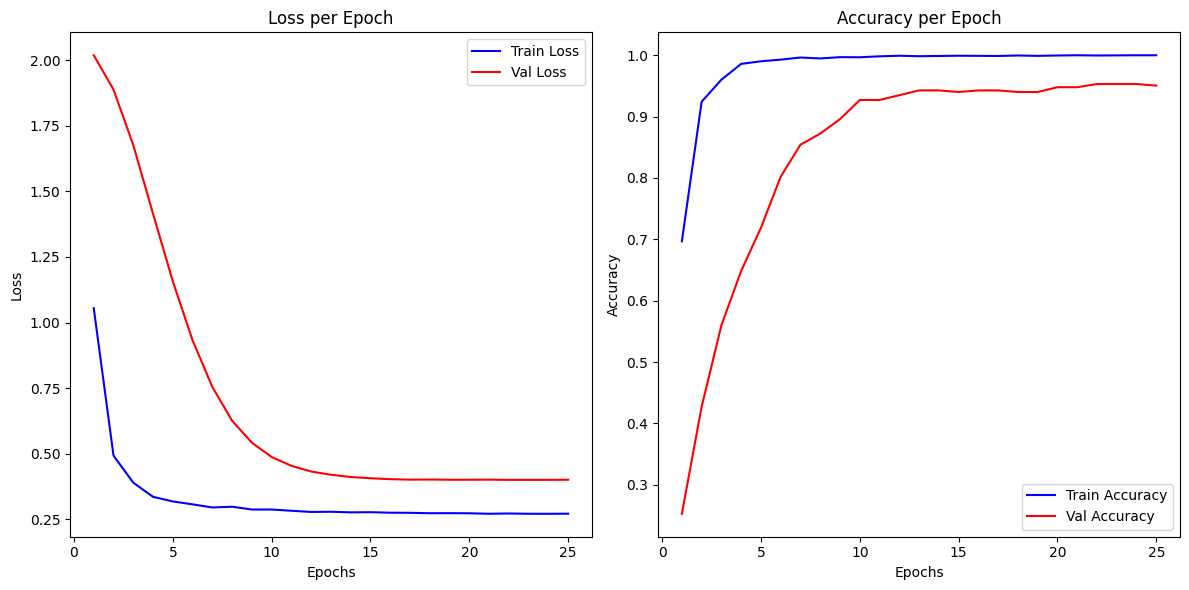

In [11]:
# EfficientNetB0
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

from torch import amp
import torch.nn.functional as F
from torchvision import transforms
import numpy as np


weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 8)
model = model.cuda()


imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.Resize(300, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


train_dataset = RiceLeafDataset(root_dir="/content/augmented_train", transform=transform)
val_dataset = RiceLeafDataset(root_dir="/content/rice-leaf-disease-dataset/val", transform=transform)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=32, shuffle=False)
}


criterion = nn.CrossEntropyLoss(label_smoothing=0.05)


optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

scaler = amp.GradScaler('cuda')


ema_decay = 0.999
ema_model = efficientnet_b0(weights=None)
ema_model.classifier[1] = nn.Linear(ema_model.classifier[1].in_features, 8)
ema_model = ema_model.cuda()
ema_model.load_state_dict(model.state_dict())
for p in ema_model.parameters():
    p.requires_grad = False

@torch.no_grad()
def _update_ema(src, dst, decay=0.999):
    msd = src.state_dict()
    dsd = dst.state_dict()
    for k, v_dst in dsd.items():
        v_src = msd[k]
        if v_dst.dtype.is_floating_point:
            dsd[k].copy_(v_dst * decay + v_src * (1.0 - decay))


@torch.no_grad()
def _tta_logits(model_eval, x):
    out1 = model_eval(x)
    out2 = model_eval(torch.flip(x, dims=[-1]))
    return (out1 + out2) / 2.0

def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25, patience=7):
    best_acc = 0.0
    early_stop_counter = 0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        model.train()
        train_loss, train_corrects = 0.0, 0

        for inputs, labels in tqdm(dataloaders['train']):
            inputs, labels = inputs.cuda(), labels.cuda()
            optimizer.zero_grad(set_to_none=True)


            with amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()


            _update_ema(model, ema_model, decay=ema_decay)

            train_loss += loss.item() * inputs.size(0)
            train_corrects += torch.sum(torch.argmax(outputs, dim=1) == labels)

        train_loss /= len(dataloaders['train'].dataset)
        train_acc = train_corrects.double() / len(dataloaders['train'].dataset)


        scheduler.step()


        ema_model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in tqdm(dataloaders['val']):
                inputs, labels = inputs.cuda(), labels.cuda()
                with amp.autocast('cuda'):
                    outputs = _tta_logits(ema_model, inputs)
                    loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(torch.argmax(outputs, dim=1) == labels)

        val_loss /= len(dataloaders['val'].dataset)
        val_acc = val_corrects.double() / len(dataloaders['val'].dataset)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc.item())
        val_accuracies.append(val_acc.item())


        if val_acc > best_acc:
            best_acc = val_acc
            early_stop_counter = 0
            torch.save(ema_model.state_dict(), '/content/drive/MyDrive/best_model_efficientnet_b0.pth')
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break

    print(f"Best Validation Accuracy (EMA+TTA): {best_acc:.4f}")
    plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', color='blue')
    plt.plot(epochs, val_losses, label='Val Loss', color='red')
    plt.title('Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy', color='blue')
    plt.plot(epochs, val_accuracies, label='Val Accuracy', color='red')
    plt.title('Accuracy per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25, patience=7)


Overall Accuracy: 94.53% (Rounded: 95%)

Confusion Matrix:
 [[42  0  0  0  1  2  0  0]
 [ 1 50  0  2  0  1  0  0]
 [ 0  0 44  0  0  0  1  0]
 [ 0  0  0 55  2  3  0  0]
 [ 2  0  0  1 41  1  0  0]
 [ 0  1  0  0  1 43  0  0]
 [ 0  0  1  0  0  0 43  1]
 [ 0  0  0  0  0  0  0 45]]
Classification Report:
                         precision    recall  f1-score   support

 Bacterial Leaf Blight       0.93      0.93      0.93        45
            Brown Spot       0.98      0.93      0.95        54
     Healthy Rice Leaf       0.98      0.98      0.98        45
            Leaf Blast       0.95      0.92      0.93        60
            Leaf scald       0.91      0.91      0.91        45
Narrow Brown Leaf Spot       0.86      0.96      0.91        45
            Rice Hispa       0.98      0.96      0.97        45
         Sheath Blight       0.98      1.00      0.99        45

              accuracy                           0.95       384
             macro avg       0.95      0.95      0.95   

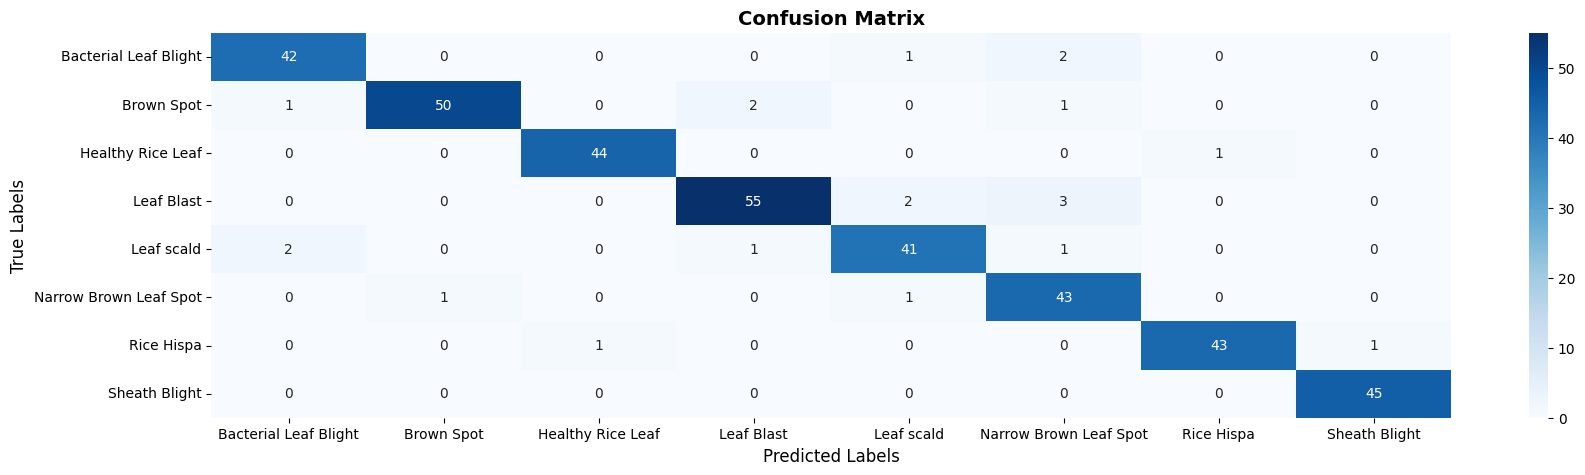

<Figure size 2000x500 with 0 Axes>

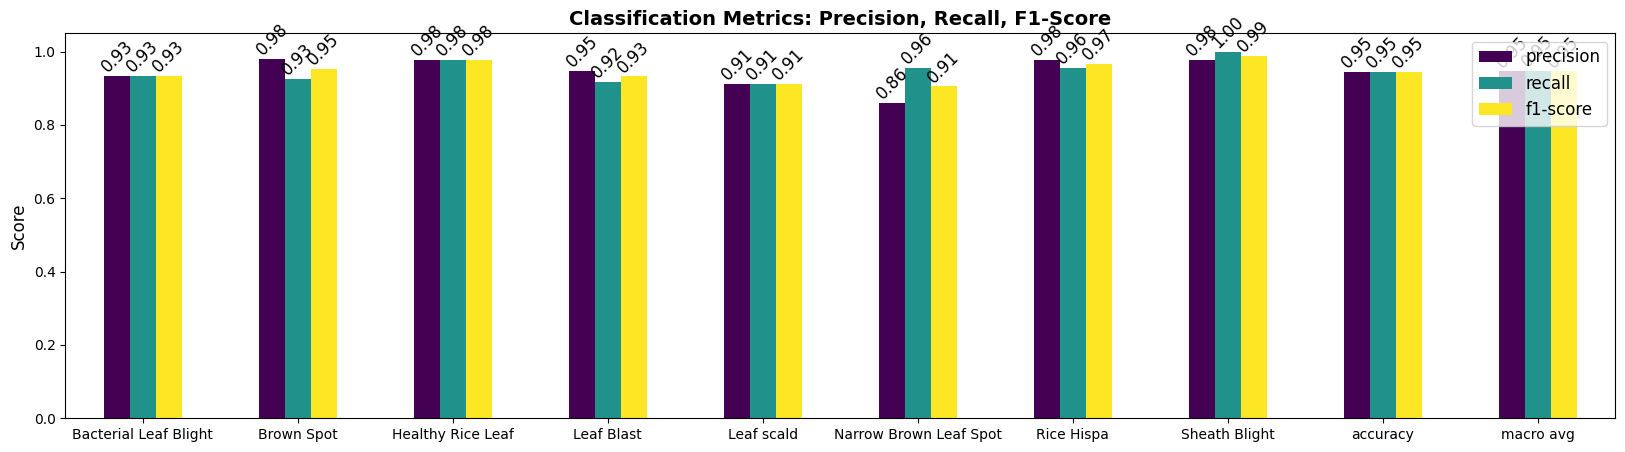

In [12]:
def evaluate_model(model, dataloader):
    model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_efficientnet_b0.pth'))
    model.eval()
    y_true, y_pred = [], []
    import os
    if os.path.exists("best_acc.txt"):
        with open("best_acc.txt", "r") as f:
            best_acc = float(f.read().strip())
    else:
        best_acc = None

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())


    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=[
        'Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast',
        'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight'
    ], output_dict=True)


    if best_acc is not None:
        print(f"\nBest Validation Accuracy (from training): {best_acc*100:.2f}% (Rounded: {round(best_acc*100)}%)\n")
    else:
        from sklearn.metrics import accuracy_score
        acc = accuracy_score(y_true, y_pred) * 100
        print(f"\nOverall Accuracy: {acc:.2f}% (Rounded: {round(acc)}%)\n")

    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=[
        'Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast',
        'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight'
    ]))

    plt.figure(figsize=(20, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast',
                             'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight'],
                yticklabels=['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast',
                             'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight'])
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.show()

    report_df = pd.DataFrame(report).transpose()
    metrics = report_df[['precision', 'recall', 'f1-score']].iloc[:-1]

    plt.figure(figsize=(20, 5))
    ax = metrics.plot(kind='bar', figsize=(20, 5), colormap='viridis')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=12, rotation=45)

    plt.title('Classification Metrics: Precision, Recall, F1-Score', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()

evaluate_model(model, dataloaders['val'])

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

/tmp/ipykernel_2090/3646714687.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



Epoch 1/25  (lr=1.67e-05)


  0%|          | 0/163 [00:00<?, ?it/s]/tmp/ipykernel_2090/3646714687.py:145: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 163/163 [00:39<00:00,  4.15it/s]
/tmp/ipykernel_2090/3646714687.py:105: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Train Loss 0.4707 | Train Acc 0.9992
Val   Loss 0.6037 | Val   Acc 0.9453

Epoch 22/25  (lr=3.97e-06)


100%|██████████| 163/163 [00:35<00:00,  4.59it/s]


Train Loss 0.4706 | Train Acc 0.9998
Val   Loss 0.6059 | Val   Acc 0.9453

Epoch 23/25  (lr=2.26e-06)


100%|██████████| 163/163 [00:36<00:00,  4.53it/s]


Train Loss 0.4706 | Train Acc 0.9996
Val   Loss 0.6066 | Val   Acc 0.9453
Early stopping triggered.

Best Validation Accuracy: 0.9453


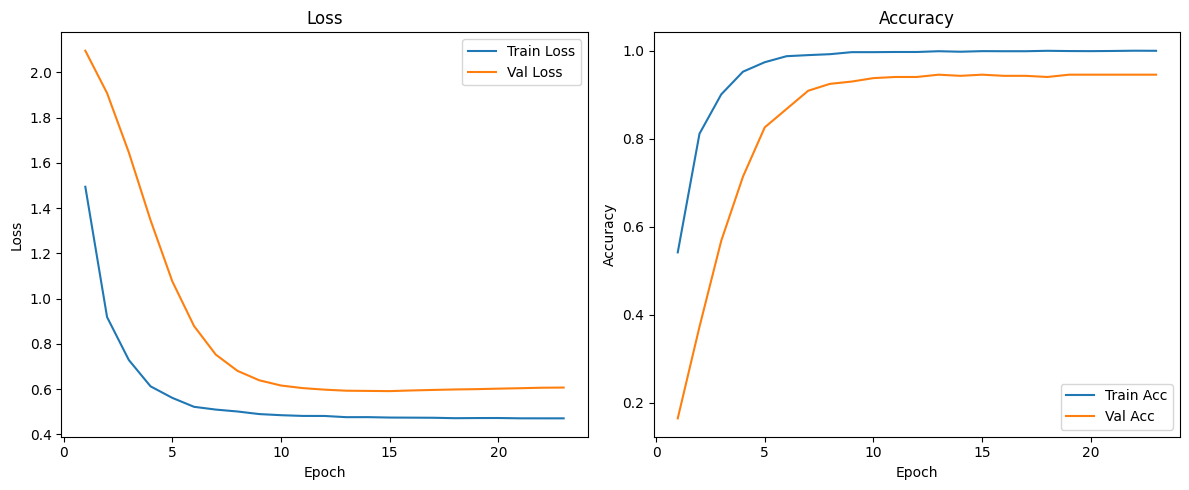

Loaded best EMA weights from disk.


In [13]:
#Swin-Tiny

import os, random, math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import timm
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
set_seed(42)

TRAIN_ROOT = "/content/augmented_train"
VAL_ROOT   = "/content/rice-leaf-disease-dataset/val"
NUM_CLASSES = 8
BATCH_SIZE = 32
EPOCHS = 25
PATIENCE = 10
INIT_LR = 5e-5
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 3
CLIP_NORM = 1.0
EMA_DECAY = 0.999


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


train_dataset = RiceLeafDataset(root_dir=TRAIN_ROOT, transform=transform)
val_dataset   = RiceLeafDataset(root_dir=VAL_ROOT,   transform=transform)

dataloaders = {
    "train": DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True),
    "val":   DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
}


model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_path_rate=0.2
)
model = model.cuda()


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=INIT_LR, weight_decay=WEIGHT_DECAY)


def lr_lambda(current_epoch):
    if current_epoch < WARMUP_EPOCHS:
        return float(current_epoch + 1) / float(max(1, WARMUP_EPOCHS))

    progress = (current_epoch - WARMUP_EPOCHS) / float(max(1, EPOCHS - WARMUP_EPOCHS))
    return 0.5 * (1.0 + math.cos(math.pi * progress))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


class ModelEMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.ema = timm.utils.ModelEmaV2(model, decay=decay)

    def update(self, model):
        self.ema.update(model)

    @torch.no_grad()
    def evaluate_model(self):
        return self.ema.module

ema_helper = ModelEMA(model, decay=EMA_DECAY)


scaler = torch.cuda.amp.GradScaler()


def accuracy_from_logits(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).sum().item()

@torch.no_grad()
def evaluate(model_eval, loader, use_tta=True):
    model_eval.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x = x.cuda(non_blocking=True); y = y.cuda(non_blocking=True)
        if use_tta:
            logits_sum = 0
            for t in range(2):
                x_in = x if t == 0 else torch.flip(x, dims=[3])
                with torch.cuda.amp.autocast():
                    out = model_eval(x_in)
                logits_sum = logits_sum + out
            logits = logits_sum / 2.0
        else:
            with torch.cuda.amp.autocast():
                logits = model_eval(x)
        loss = criterion(logits, y)
        loss_sum += loss.item() * x.size(0)
        correct  += accuracy_from_logits(logits, y)
        total    += x.size(0)
    return loss_sum / total, correct / total

def plot_history(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss")
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accs, label="Train Acc")
    plt.plot(epochs, val_accs, label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy")
    plt.tight_layout(); plt.show()

def train(model, dataloaders, epochs=EPOCHS, patience=PATIENCE):
    best_acc = 0.0
    best_path = "/content/drive/MyDrive/best_model_swin_tiny.pth"
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    early = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}  (lr={scheduler.get_last_lr()[0]:.2e})")
        model.train()
        total, correct, loss_sum = 0, 0, 0.0

        for x, y in tqdm(dataloaders["train"]):
            x = x.cuda(non_blocking=True); y = y.cuda(non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()

            ema_helper.update(model)

            loss_sum += loss.item() * x.size(0)
            correct  += accuracy_from_logits(logits, y)
            total    += x.size(0)

        scheduler.step()

        train_loss = loss_sum / total
        train_acc  = correct / total


        val_loss, val_acc = evaluate(ema_helper.evaluate_model(), dataloaders["val"], use_tta=True)

        print(f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f}")
        print(f"Val   Loss {val_loss:.4f} | Val   Acc {val_acc:.4f}")

        train_losses.append(train_loss);  val_losses.append(val_loss)
        train_accs.append(train_acc);     val_accs.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            early = 0
            torch.save(ema_helper.evaluate_model().state_dict(), best_path)
        else:
            early += 1
            if early >= patience:
                print("Early stopping triggered.")
                break

    print(f"\nBest Validation Accuracy: {best_acc:.4f}")
    plot_history(train_losses, val_losses, train_accs, val_accs)
    return best_acc

best_val_acc = train(model, dataloaders, epochs=EPOCHS, patience=PATIENCE)

model.load_state_dict(torch.load("/content/drive/MyDrive/best_model_swin_tiny.pth"))
model.eval()
print("Loaded best EMA weights from disk.")

Confusion Matrix:
 [[43  0  0  0  1  1  0  0]
 [ 0 50  0  0  0  4  0  0]
 [ 0  0 45  0  0  0  0  0]
 [ 2  1  0 53  3  0  0  1]
 [ 2  1  0  1 41  0  0  0]
 [ 1  0  0  0  1 43  0  0]
 [ 0  0  0  0  0  0 45  0]
 [ 1  0  0  0  1  0  0 43]]
Classification Report:
                         precision    recall  f1-score   support

 Bacterial Leaf Blight       0.88      0.96      0.91        45
            Brown Spot       0.96      0.93      0.94        54
     Healthy Rice Leaf       1.00      1.00      1.00        45
            Leaf Blast       0.98      0.88      0.93        60
            Leaf scald       0.87      0.91      0.89        45
Narrow Brown Leaf Spot       0.90      0.96      0.92        45
            Rice Hispa       1.00      1.00      1.00        45
         Sheath Blight       0.98      0.96      0.97        45

              accuracy                           0.95       384
             macro avg       0.95      0.95      0.95       384
          weighted avg       0.95 

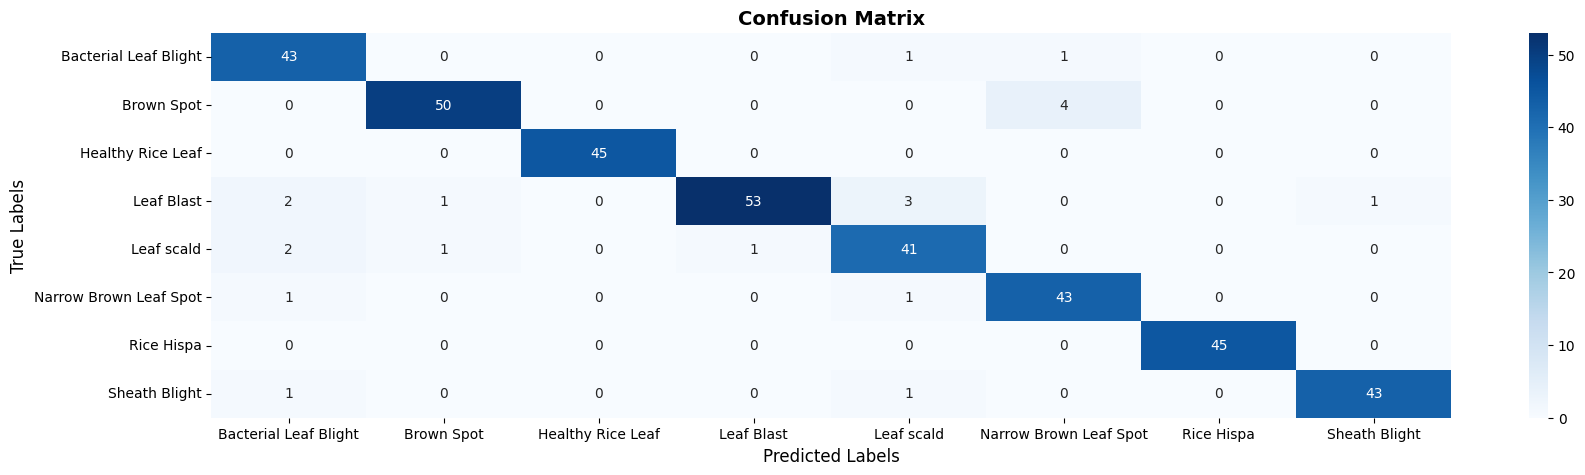

<Figure size 2000x500 with 0 Axes>

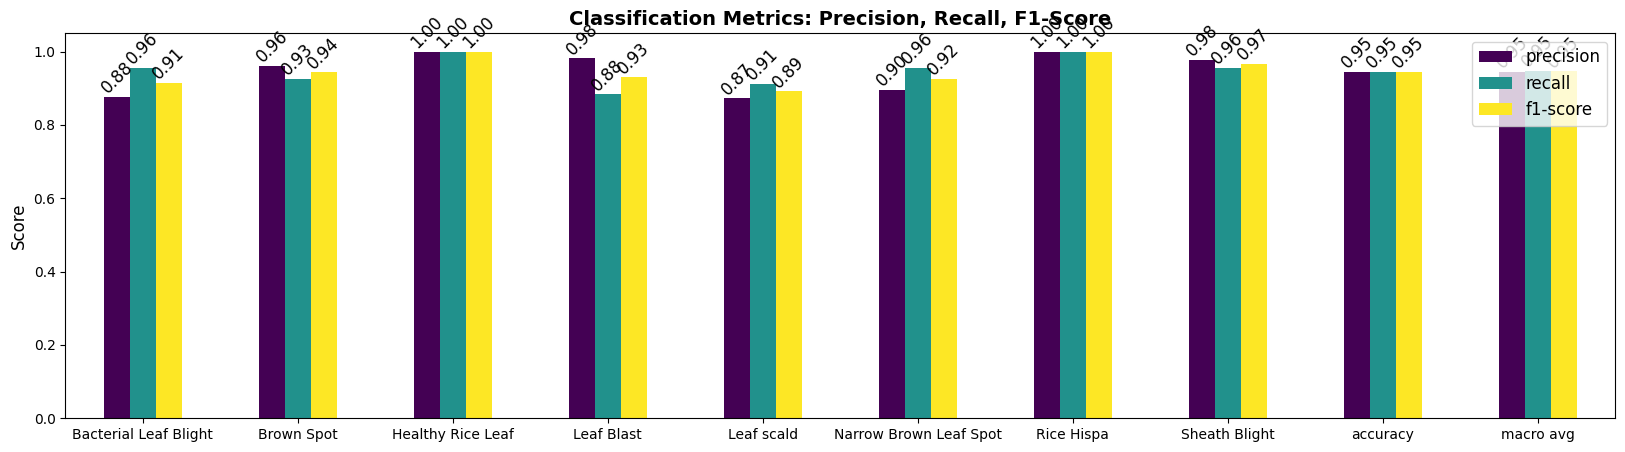

In [14]:
def evaluate_model(model, dataloader):
    model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_swin_tiny.pth'))
    model = model.cuda()
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    classes = ['Bacterial Leaf Blight','Brown Spot','Healthy Rice Leaf','Leaf Blast','Leaf scald','Narrow Brown Leaf Spot','Rice Hispa','Sheath Blight']
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)

    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=classes))

    plt.figure(figsize=(20, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.show()

    report_df = pd.DataFrame(report).transpose()
    metrics = report_df[['precision', 'recall', 'f1-score']].iloc[:-1]

    plt.figure(figsize=(20, 5))
    ax = metrics.plot(kind='bar', figsize=(20, 5), colormap='viridis')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=12, rotation=45)

    plt.title('Classification Metrics: Precision, Recall, F1-Score', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()

evaluate_model(model, dataloaders['val'])

Confusion Matrix:
 [[43  0  0  0  1  1  0  0]
 [ 0 50  0  0  0  4  0  0]
 [ 0  0 45  0  0  0  0  0]
 [ 2  1  0 53  3  0  0  1]
 [ 2  1  0  1 41  0  0  0]
 [ 1  0  0  0  1 43  0  0]
 [ 0  0  0  0  0  0 45  0]
 [ 1  0  0  0  1  0  0 43]]

Classification Report:

                       precision recall  f1-score  support
Bacterial Leaf Blight       0.88   0.96      0.91     45.0
Brown Spot                  0.96   0.93      0.94     54.0
Healthy Rice Leaf            1.0    1.0      1.00     45.0
Leaf Blast                  0.98   0.88      0.93     60.0
Leaf scald                  0.87   0.91      0.89     45.0
Narrow Brown Leaf Spot       0.9   0.96      0.92     45.0
Rice Hispa                   1.0    1.0      1.00     45.0
Sheath Blight               0.98   0.96      0.97     45.0


             precision recall  f1-score  support
accuracy                           0.95     0.95
macro avg         0.95   0.95      0.95   384.00
weighted avg      0.95   0.95      0.95   384.00


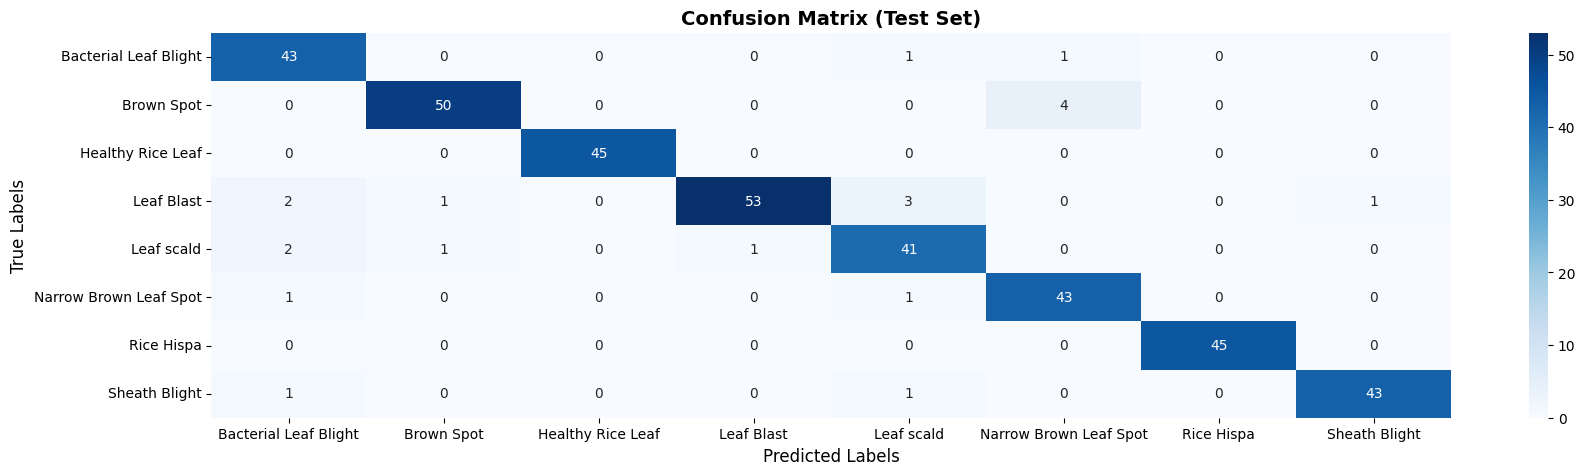

<Figure size 2000x500 with 0 Axes>

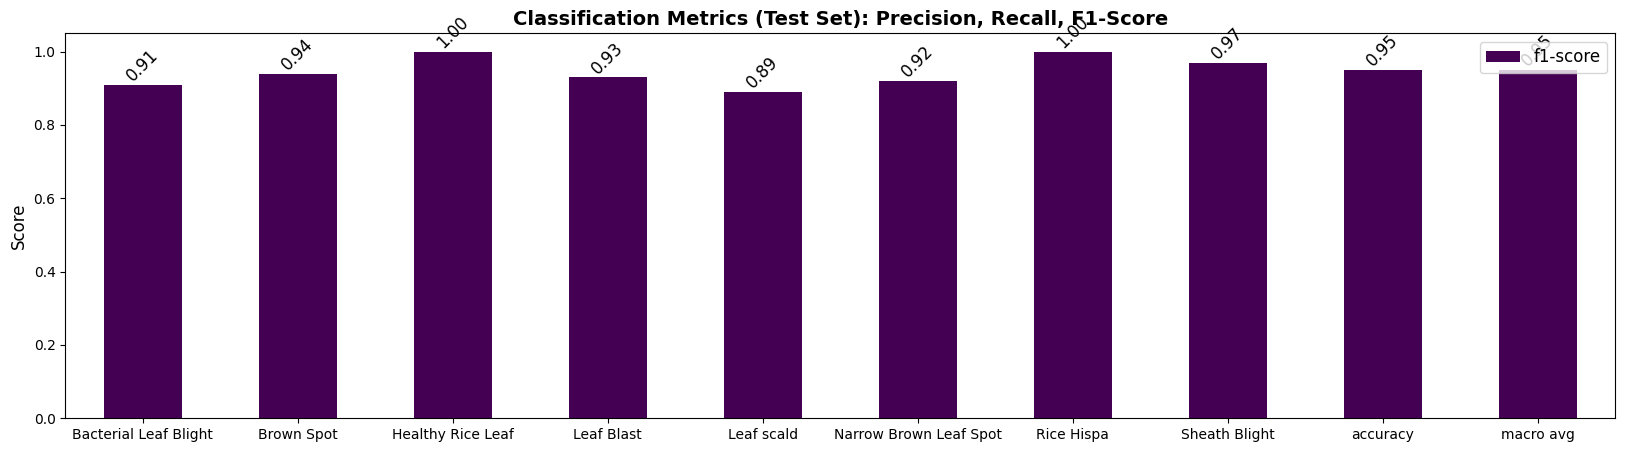

In [15]:
def evaluate_model(model, dataloader):
    import torch
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix, classification_report


    model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_swin_tiny.pth'))
    model = model.cuda()
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())


    classes = [
        'Bacterial Leaf Blight','Brown Spot','Healthy Rice Leaf','Leaf Blast',
        'Leaf scald','Narrow Brown Leaf Spot','Rice Hispa','Sheath Blight'
    ]


    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)


    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(2)


    report_df[['precision', 'recall']] = report_df[['precision', 'recall']].astype(object)
    if 'accuracy' in report_df.index:
        report_df.loc['accuracy', ['precision', 'recall']] = ''

    disease_rows = report_df.iloc[:-3]
    summary_rows = report_df.iloc[-3:]

    print("\nClassification Report:\n")
    print(disease_rows.to_string())
    print("\n")
    print(summary_rows.to_string())


    plt.figure(figsize=(20, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.show()


    metrics = report_df[['precision', 'recall', 'f1-score']].iloc[:-1]
    plt.figure(figsize=(20, 5))
    ax = metrics.plot(kind='bar', figsize=(20, 5), colormap='viridis')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=12, rotation=45)

    plt.title('Classification Metrics (Test Set): Precision, Recall, F1-Score', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()

evaluate_model(model, dataloaders['val'])

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            


Epoch 1/40


100%|██████████| 12/12 [00:02<00:00,  5.38it/s]


Train  Loss: 2.1073 | Acc: 0.1735
Val    Loss: 1.7856 | Acc: 0.3542

Epoch 2/40


...

Train  Loss: 0.0019 | Acc: 0.9998
Val    Loss: 0.3173 | Acc: 0.9505

Epoch 28/40


100%|██████████| 12/12 [00:03<00:00,  3.46it/s]


Train  Loss: 0.0009 | Acc: 0.9998
Val    Loss: 0.3000 | Acc: 0.9557

Epoch 29/40


100%|██████████| 12/12 [00:02<00:00,  4.10it/s]


Train  Loss: 0.0000 | Acc: 1.0000
Val    Loss: 0.3684 | Acc: 0.9479
Early stopping triggered.
✅ Best Validation Accuracy: 0.9609


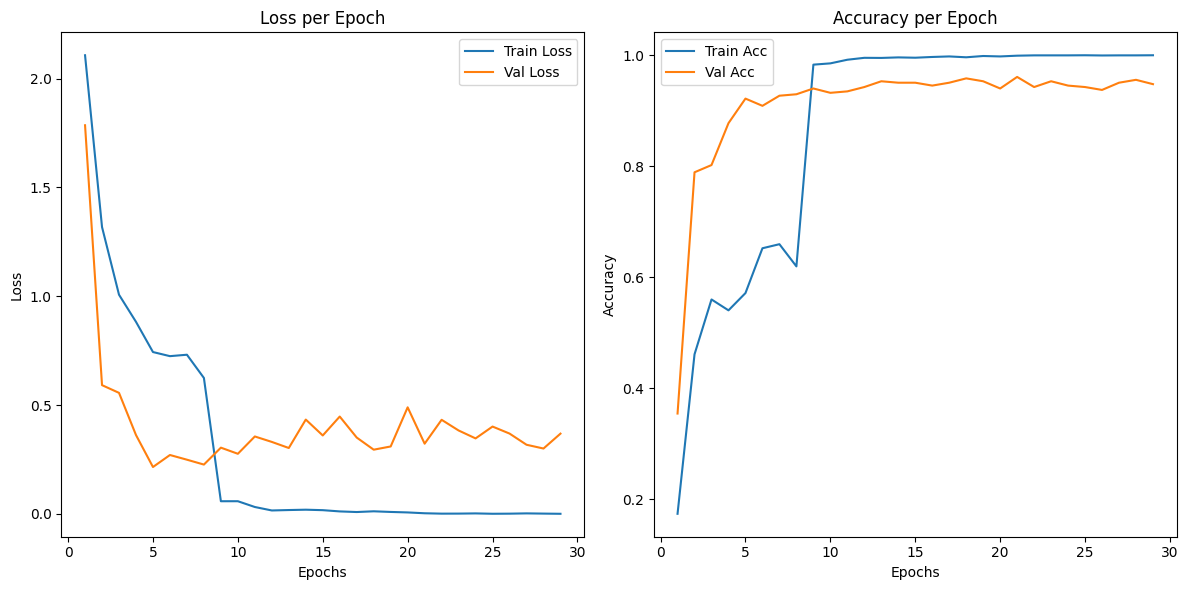

In [16]:
# ConvNeXt-Tiny (timm)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import copy, math, timm
from timm.data import resolve_model_data_config, create_transform, Mixup
from timm.loss import SoftTargetCrossEntropy
from timm.scheduler import CosineLRScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True

class ModelEMA:
    def __init__(self, model, decay=0.9998, updates=0):
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay
        self.updates = updates
        for p in self.ema.parameters():
            p.requires_grad_(False)

    def update(self, model):
        self.updates += 1
        d = self.decay * (1 - math.exp(-self.updates / 2000.0))
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(msd[k].detach(), alpha=(1.0 - d))

    def state_dict(self):
        return self.ema.state_dict()


model = timm.create_model(
    "convnext_tiny.in12k_ft_in1k",
    pretrained=True,
    drop_path_rate=0.1
)
in_features = model.head.fc.in_features
model.head.fc = nn.Linear(in_features, 8)
model = model.to(device)


data_config = resolve_model_data_config(model)
transform = create_transform(**data_config)



train_dataset = RiceLeafDataset("/content/augmented_train", transform=transform)
val_dataset   = RiceLeafDataset("/content/rice-leaf-disease-dataset/val", transform=transform)

BATCH_SIZE = 32
dataloaders = {
    "train": DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True),
    "val":   DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
}

mixup_fn = Mixup(
    mixup_alpha=0.2, cutmix_alpha=1.0,
    prob=1.0, switch_prob=0.5,
    mode="batch", label_smoothing=0.0, num_classes=8
)


optimizer = torch.optim.AdamW(model.parameters(), lr=6e-5, weight_decay=1e-4)


NUM_EPOCHS = 40
scheduler = CosineLRScheduler(
    optimizer,
    t_initial=NUM_EPOCHS,
    lr_min=1e-6,
    warmup_t=5,
    warmup_lr_init=1e-6,
    k_decay=1.0
)


mixup_criterion = SoftTargetCrossEntropy()
ce_criterion    = nn.CrossEntropyLoss(label_smoothing=0.05)


scaler = torch.amp.GradScaler(device if device == "cuda" else "cpu")


@torch.no_grad()
def tta_logits(m, x):
    y1 = m(x)
    y2 = m(torch.flip(x, dims=[3]))
    return (y1 + y2) / 2.0


def train_model(model, dataloaders, optimizer, scheduler, num_epochs=NUM_EPOCHS, patience=8, mixup_epochs=8):
    ema = ModelEMA(model, decay=0.9998)
    best_acc, es = 0.0, 0

    tr_losses, va_losses, tr_accs, va_accs = [], [], [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        model.train()
        running_loss, running_corrects, n_train = 0.0, 0, 0

        use_mixup = epoch < mixup_epochs

        for images, labels in tqdm(dataloaders["train"]):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            if use_mixup:
                inputs, targets = mixup_fn(images, labels)
                criterion = mixup_criterion
            else:
                inputs = images
                targets = torch.nn.functional.one_hot(labels, num_classes=8).float()
                criterion = mixup_criterion if targets.ndim == 2 else ce_criterion

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device, enabled=(device=="cuda")):
                outputs = model(inputs)
                loss = criterion(outputs, targets)


            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            ema.update(model)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            running_corrects += (preds == labels).sum().item()
            n_train += images.size(0)

        train_loss = running_loss / n_train
        train_acc  = running_corrects / n_train


        model.eval(); ema.ema.eval()
        v_loss, v_corrects, n_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(dataloaders["val"]):
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                with torch.amp.autocast(device_type=device, enabled=(device=="cuda")):
                    logits = tta_logits(ema.ema, images)
                    loss = nn.CrossEntropyLoss()(logits, labels)
                v_loss += loss.item() * images.size(0)
                v_corrects += (logits.argmax(1) == labels).sum().item()
                n_val += images.size(0)

        val_loss = v_loss / n_val
        val_acc  = v_corrects / n_val

        print(f"Train  Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"Val    Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

        tr_losses.append(train_loss); va_losses.append(val_loss)
        tr_accs.append(train_acc);   va_accs.append(val_acc)


        scheduler.step(epoch + 1)


        if val_acc > best_acc:
            best_acc, es = val_acc, 0
            torch.save(ema.state_dict(), "/content/drive/MyDrive/best_model_convnext_tiny_timm_ema_smooth.pth")
        else:
            es += 1
            if es >= patience:
                print("Early stopping triggered.")
                break

    print(f"✅ Best Validation Accuracy: {best_acc:.4f}")
    plot_training_history(tr_losses, va_losses, tr_accs, va_accs)

def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.title('Loss per Epoch'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Acc')
    plt.plot(epochs, val_accuracies, label='Val Acc')
    plt.title('Accuracy per Epoch'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()
    plt.tight_layout(); plt.show()

train_model(model, dataloaders, optimizer, scheduler, num_epochs=NUM_EPOCHS, patience=8, mixup_epochs=8)


Confusion Matrix:
 [[44  0  0  0  0  1  0  0]
 [ 0 51  0  0  0  3  0  0]
 [ 0  0 45  0  0  0  0  0]
 [ 1  1  0 55  1  2  0  0]
 [ 3  0  0  2 39  0  0  1]
 [ 1  0  0  1  0 43  0  0]
 [ 0  0  0  0  1  0 44  0]
 [ 0  0  0  0  0  0  0 45]]
Classification Report:
                         precision    recall  f1-score   support

 Bacterial Leaf Blight       0.90      0.98      0.94        45
            Brown Spot       0.98      0.94      0.96        54
     Healthy Rice Leaf       1.00      1.00      1.00        45
            Leaf Blast       0.95      0.92      0.93        60
            Leaf scald       0.95      0.87      0.91        45
Narrow Brown Leaf Spot       0.88      0.96      0.91        45
            Rice Hispa       1.00      0.98      0.99        45
         Sheath Blight       0.98      1.00      0.99        45

              accuracy                           0.95       384
             macro avg       0.95      0.95      0.95       384
          weighted avg       0.95 

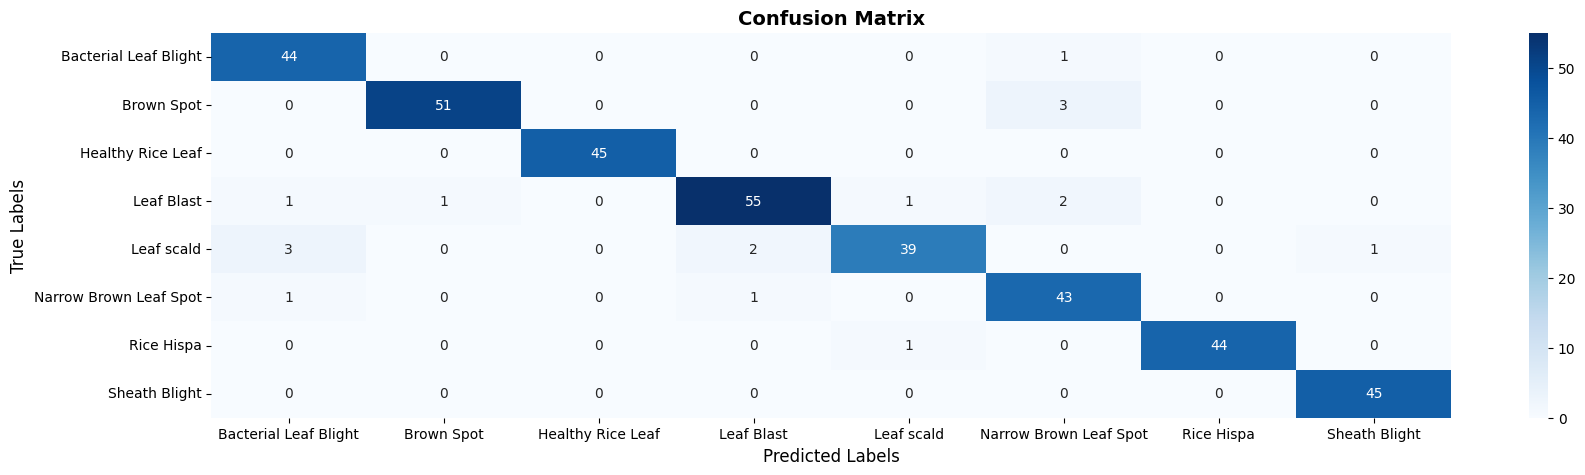

<Figure size 2000x500 with 0 Axes>

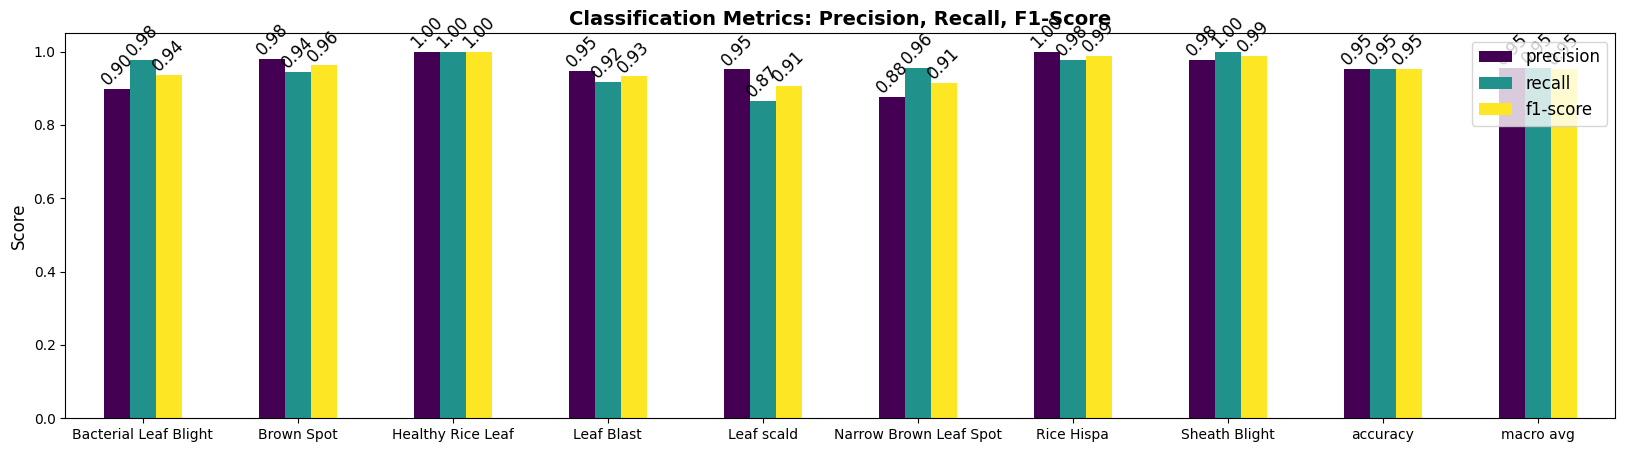

In [17]:
def evaluate_model(model, dataloader):
    model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_convnext_tiny_timm_ema_smooth.pth'))
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    classes = ['Bacterial Leaf Blight','Brown Spot','Healthy Rice Leaf','Leaf Blast','Leaf scald','Narrow Brown Leaf Spot','Rice Hispa','Sheath Blight']
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)

    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=classes))

    plt.figure(figsize=(20, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.show()

    report_df = pd.DataFrame(report).transpose()
    metrics = report_df[['precision', 'recall', 'f1-score']].iloc[:-1]

    plt.figure(figsize=(20, 5))
    ax = metrics.plot(kind='bar', figsize=(20, 5), colormap='viridis')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=12, rotation=45)

    plt.title('Classification Metrics: Precision, Recall, F1-Score', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()

evaluate_model(model, dataloaders['val'])

✅ Loaded best ConvNeXt-Tiny weights successfully.
Confusion Matrix:
 [[45  0  0  0  0  0  0  0]
 [ 1 49  0  1  1  2  1  0]
 [ 0  0 45  0  0  0  0  0]
 [ 1  0  0 57  0  2  0  0]
 [ 3  0  0  0 39  3  0  0]
 [ 1  0  0  1  1 42  0  0]
 [ 0  0  0  0  0  0 45  0]
 [ 0  0  0  0  0  0  0 45]]

Classification Report:

                       precision recall  f1-score  support
Bacterial Leaf Blight       0.88    1.0      0.94     45.0
Brown Spot                   1.0   0.89      0.94     55.0
Healthy Rice Leaf            1.0    1.0      1.00     45.0
Leaf Blast                  0.97   0.95      0.96     60.0
Leaf scald                  0.95   0.87      0.91     45.0
Narrow Brown Leaf Spot      0.86   0.93      0.89     45.0
Rice Hispa                  0.98    1.0      0.99     45.0
Sheath Blight                1.0    1.0      1.00     45.0


             precision recall  f1-score  support
accuracy                           0.95     0.95
macro avg         0.95   0.96      0.95   385.00
weighted 

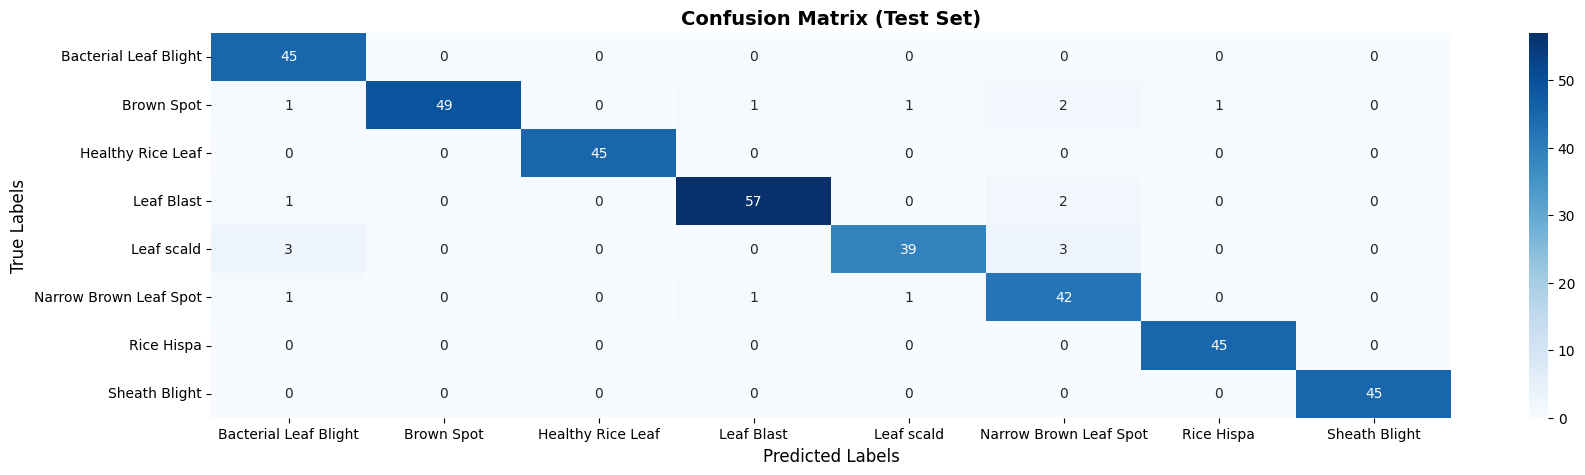

<Figure size 2000x500 with 0 Axes>

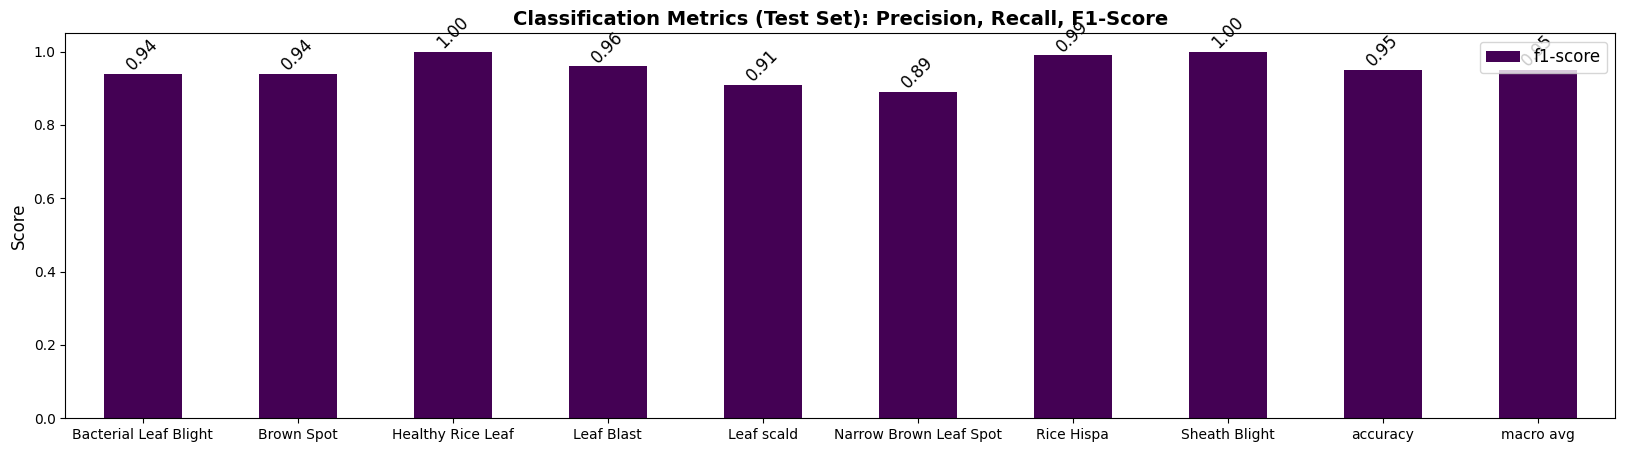

In [18]:
# ===============
# ConvNeXt-Tiny
# ===============
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader
from torchvision import transforms


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

TEST_ROOT = "/content/rice-leaf-disease-dataset/test"
test_dataset = RiceLeafDataset(root_dir=TEST_ROOT, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

import timm
model = timm.create_model(
    "convnext_tiny.in12k_ft_in1k",
    pretrained=False,
    drop_path_rate=0.1,
    num_classes=8
)
in_features = model.head.fc.in_features
model.head.fc = torch.nn.Linear(in_features, 8)
model = model.cuda()


model.load_state_dict(torch.load("/content/drive/MyDrive/best_model_convnext_tiny_timm_ema_smooth.pth"))
model.eval()
print("✅ Loaded best ConvNeXt-Tiny weights successfully.")


def evaluate_model(model, dataloader):
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())


    classes = [
        'Bacterial Leaf Blight','Brown Spot','Healthy Rice Leaf','Leaf Blast',
        'Leaf scald','Narrow Brown Leaf Spot','Rice Hispa','Sheath Blight'
    ]


    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)


    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(2)


    report_df[['precision', 'recall']] = report_df[['precision', 'recall']].astype(object)
    if 'accuracy' in report_df.index:
        report_df.loc['accuracy', ['precision', 'recall']] = ''

    disease_rows = report_df.iloc[:-3]
    summary_rows = report_df.iloc[-3:]

    print("\nClassification Report:\n")
    print(disease_rows.to_string())
    print("\n")
    print(summary_rows.to_string())


    plt.figure(figsize=(20, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.show()


    metrics = report_df[['precision', 'recall', 'f1-score']].iloc[:-1]
    plt.figure(figsize=(20, 5))
    ax = metrics.plot(kind='bar', figsize=(20, 5), colormap='viridis')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=12, rotation=45)
    plt.title('Classification Metrics (Test Set): Precision, Recall, F1-Score', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()

evaluate_model(model, test_loader)


model.safetensors: reconstructing file:   0%|          |  0.00B /  113MB            

model.safetensors: downloading bytes:           |  0.00B            

/tmp/ipykernel_2090/528553294.py:113: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Epoch 1/25


  0%|          | 0/163 [00:00<?, ?it/s]/tmp/ipykernel_2090/528553294.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
  0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_2090/528553294.py:165: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 12/12 [00:02<00:00,  4.36it/s]


...

Train Loss: 0.5216, Train Acc: 1.0000
Val   Loss: 0.6114, Val   Acc: 0.9661

Epoch 19/25


100%|██████████| 12/12 [00:02<00:00,  4.25it/s]


Train Loss: 0.5218, Train Acc: 0.9996
Val   Loss: 0.6143, Val   Acc: 0.9661

Epoch 20/25


100%|██████████| 12/12 [00:02<00:00,  4.18it/s]


Train Loss: 0.5215, Train Acc: 0.9998
Val   Loss: 0.6168, Val   Acc: 0.9609
Early stopping triggered.
Best Validation Accuracy (EMA+TTA): 0.9714


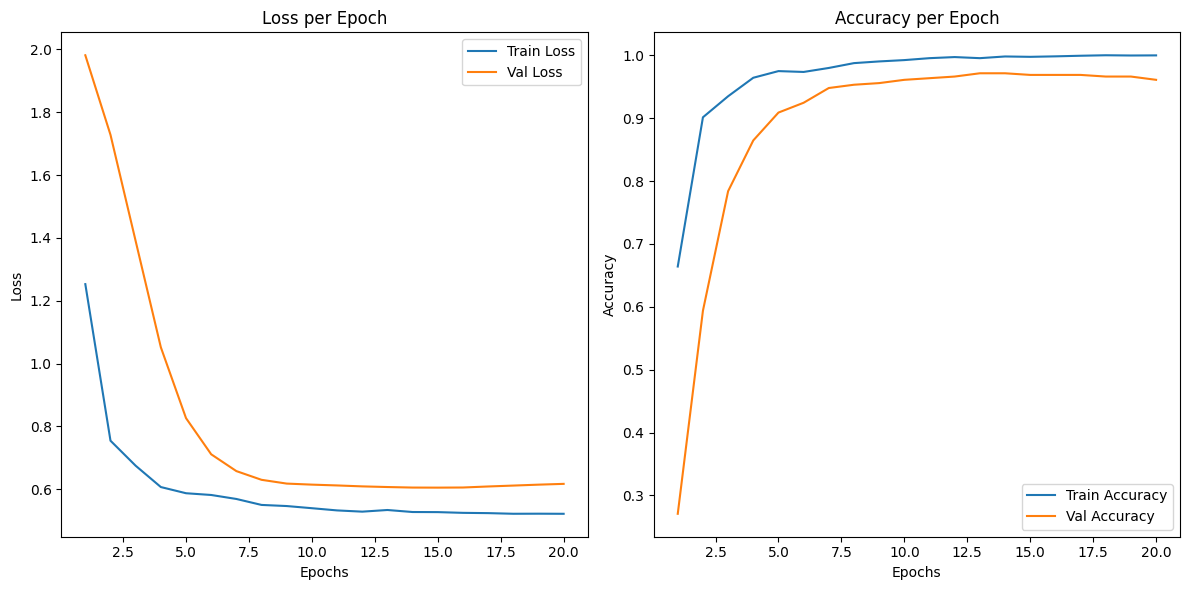

In [19]:
# DaViT-Tiny

import math, copy, torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
from torchvision import transforms

# ---------
# DaViT
# ---------


model = timm.create_model(
    'davit_tiny',
    pretrained=True,
    drop_rate=0.20,
    drop_path_rate=0.10
)


if hasattr(model, 'reset_classifier'):
    model.reset_classifier(num_classes=8)
else:
    if hasattr(model, 'head') and hasattr(model.head, 'in_features'):
        in_feats = model.head.in_features
        model.head = nn.Linear(in_feats, 8)
    else:
        raise RuntimeError("Unable to set classifier automatically. Check model attributes.")

model = model.cuda()


class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):

        n_classes = pred.size(-1)
        log_probs = F.log_softmax(pred, dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        return torch.mean(torch.sum(-true_dist * log_probs, dim=-1))

criterion = LabelSmoothingCE(smoothing=0.10)


base_lr = 3e-4
weight_decay = 5e-2
optimizer = AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay, betas=(0.9, 0.999))

num_epochs = 25
warmup_epochs = 3

def lr_lambda(current_epoch):
    if current_epoch < warmup_epochs:

        return float(current_epoch + 1) / float(max(1, warmup_epochs))

    progress = (current_epoch - warmup_epochs) / float(max(1, num_epochs - warmup_epochs))
    return 0.1 + 0.9 * 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval().requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if k in msd:
                v.copy_(v * self.decay + msd[k].detach() * (1.0 - self.decay))

ema = ModelEMA(model, decay=0.999)


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


train_dataset = RiceLeafDataset(root_dir="/content/augmented_train", transform=transform)
val_dataset   = RiceLeafDataset(root_dir="/content/rice-leaf-disease-dataset/val", transform=transform)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val':   DataLoader(val_dataset,   batch_size=32, shuffle=False)
}


@torch.no_grad()
def predict_with_tta(model, inputs):
    logits = model(inputs)
    logits_flip = model(torch.flip(inputs, dims=[3]))
    return (logits + logits_flip) * 0.5

scaler = GradScaler()

def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25, patience=7):
    best_acc = 0.0
    early_stop_counter = 0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")


        model.train()
        epoch_train_loss, train_corrects, seen = 0.0, 0, 0

        for inputs, labels in tqdm(dataloaders['train']):
            inputs, labels = inputs.cuda(non_blocking=True), labels.cuda(non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            ema.update(model)

            batch_size = inputs.size(0)
            epoch_train_loss += loss.item() * batch_size
            train_corrects += torch.sum(torch.argmax(outputs, dim=1) == labels).item()
            seen += batch_size

        train_loss = epoch_train_loss / max(1, seen)
        train_acc  = train_corrects / max(1, seen)

        scheduler.step()


        model.eval()
        val_loss_cum, val_corrects, val_seen = 0.0, 0, 0


        eval_model = ema.ema
        eval_model.eval()

        with torch.no_grad():
            for inputs, labels in tqdm(dataloaders['val']):
                inputs, labels = inputs.cuda(non_blocking=True), labels.cuda(non_blocking=True)
                with autocast():
                    logits = predict_with_tta(eval_model, inputs)
                    loss = criterion(logits, labels)

                batch_size = inputs.size(0)
                val_loss_cum += loss.item() * batch_size
                preds = torch.argmax(logits, dim=1)
                val_corrects += torch.sum(preds == labels).item()
                val_seen += batch_size

        val_loss = val_loss_cum / max(1, val_seen)
        val_acc  = val_corrects / max(1, val_seen)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)


        if val_acc > best_acc:
            best_acc = val_acc
            early_stop_counter = 0
            torch.save(eval_model.state_dict(), '/content/drive/MyDrive/best_model_davit_tiny.pth')
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break

    print(f"Best Validation Accuracy (EMA+TTA): {best_acc:.4f}")
    plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.title('Loss per Epoch'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.title('Accuracy per Epoch'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

    plt.tight_layout(); plt.show()


train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25, patience=7)


Confusion Matrix:
 [[43  1  0  0  0  1  0  0]
 [ 0 52  0  0  0  2  0  0]
 [ 0  0 44  0  1  0  0  0]
 [ 0  1  0 55  3  1  0  0]
 [ 3  0  0  0 42  0  0  0]
 [ 0  1  0  0  0 44  0  0]
 [ 0  0  0  0  0  0 44  1]
 [ 0  0  0  0  1  0  0 44]]
Classification Report:
                         precision    recall  f1-score   support

 Bacterial Leaf Blight       0.93      0.96      0.95        45
            Brown Spot       0.95      0.96      0.95        54
     Healthy Rice Leaf       1.00      0.98      0.99        45
            Leaf Blast       1.00      0.92      0.96        60
            Leaf scald       0.89      0.93      0.91        45
Narrow Brown Leaf Spot       0.92      0.98      0.95        45
            Rice Hispa       1.00      0.98      0.99        45
         Sheath Blight       0.98      0.98      0.98        45

              accuracy                           0.96       384
             macro avg       0.96      0.96      0.96       384
          weighted avg       0.96 

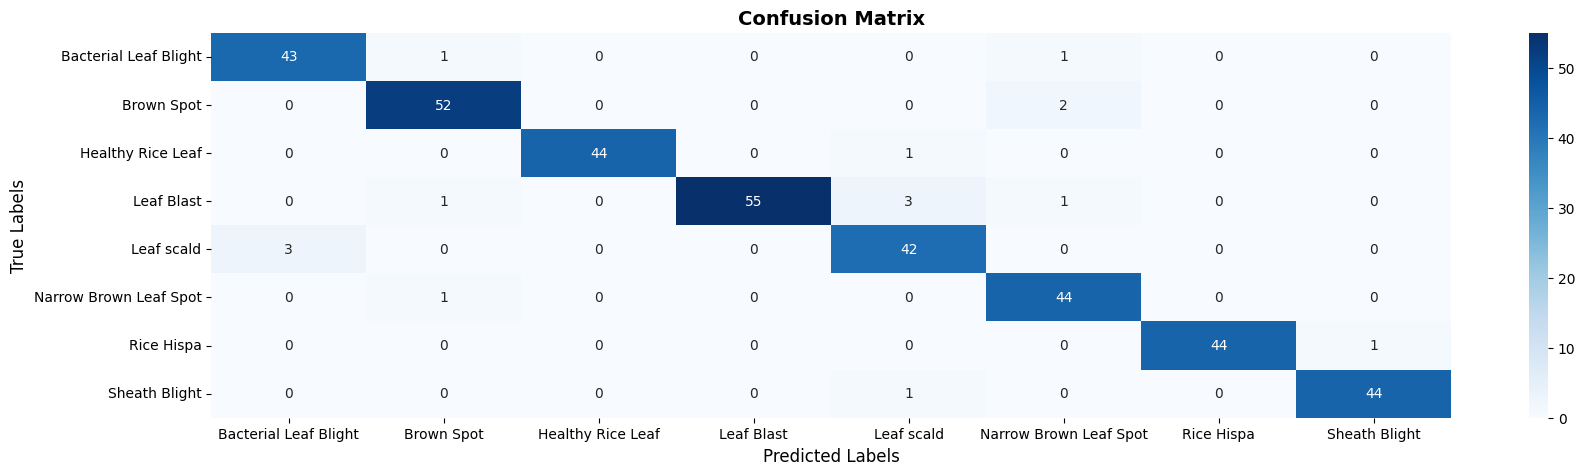

<Figure size 2000x500 with 0 Axes>

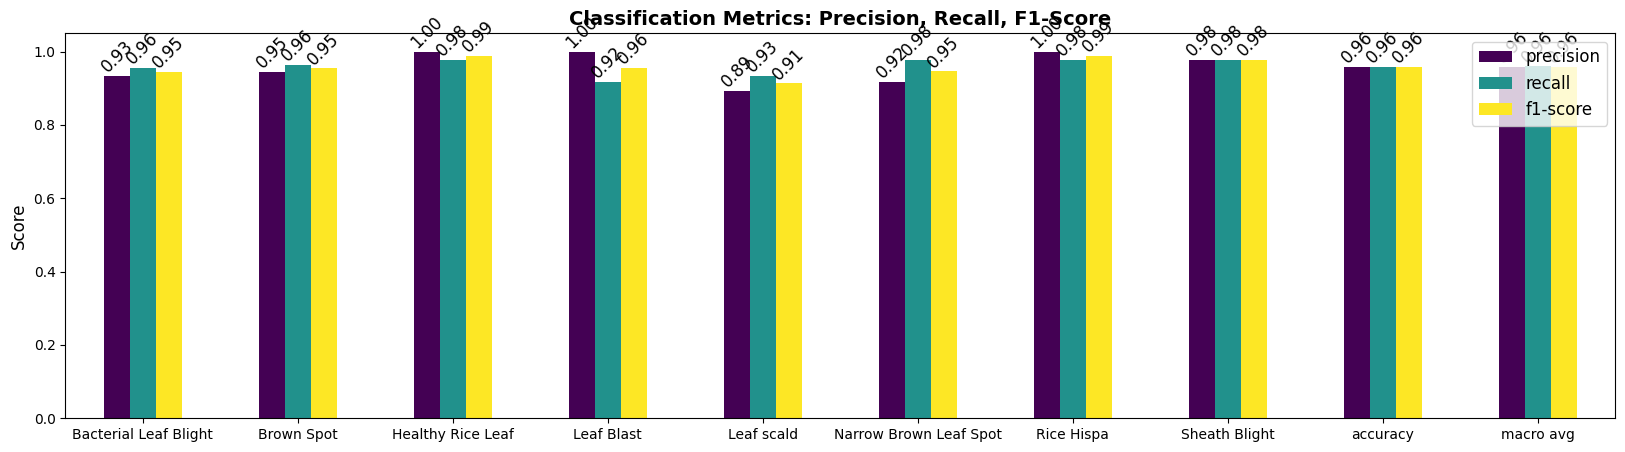

In [20]:
def evaluate_model(model, dataloader):
    model.load_state_dict(torch.load('/content/drive/MyDrive/best_model_davit_tiny.pth'))
    model = model.cuda()
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    classes = ['Bacterial Leaf Blight','Brown Spot','Healthy Rice Leaf','Leaf Blast','Leaf scald','Narrow Brown Leaf Spot','Rice Hispa','Sheath Blight']
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)

    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=classes))

    plt.figure(figsize=(20, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.show()

    report_df = pd.DataFrame(report).transpose()
    metrics = report_df[['precision', 'recall', 'f1-score']].iloc[:-1]

    plt.figure(figsize=(20, 5))
    ax = metrics.plot(kind='bar', figsize=(20, 5), colormap='viridis')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=12, rotation=45)

    plt.title('Classification Metrics: Precision, Recall, F1-Score', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()


evaluate_model(model, dataloaders['val'])

✅ Loaded best DaViT-Tiny weights successfully.
Confusion Matrix:
 [[45  0  0  0  0  0  0  0]
 [ 0 53  0  0  0  2  0  0]
 [ 0  0 43  0  2  0  0  0]
 [ 1  1  0 55  1  2  0  0]
 [ 2  0  0  0 40  3  0  0]
 [ 0  0  0  1  1 43  0  0]
 [ 0  0  0  0  0  0 45  0]
 [ 0  0  0  0  1  0  0 44]]

Classification Report:

                       precision recall  f1-score  support
Bacterial Leaf Blight       0.94    1.0      0.97     45.0
Brown Spot                  0.98   0.96      0.97     55.0
Healthy Rice Leaf            1.0   0.96      0.98     45.0
Leaf Blast                  0.98   0.92      0.95     60.0
Leaf scald                  0.89   0.89      0.89     45.0
Narrow Brown Leaf Spot      0.86   0.96      0.91     45.0
Rice Hispa                   1.0    1.0      1.00     45.0
Sheath Blight                1.0   0.98      0.99     45.0


             precision recall  f1-score  support
accuracy                           0.96     0.96
macro avg         0.96   0.96      0.96   385.00
weighted avg

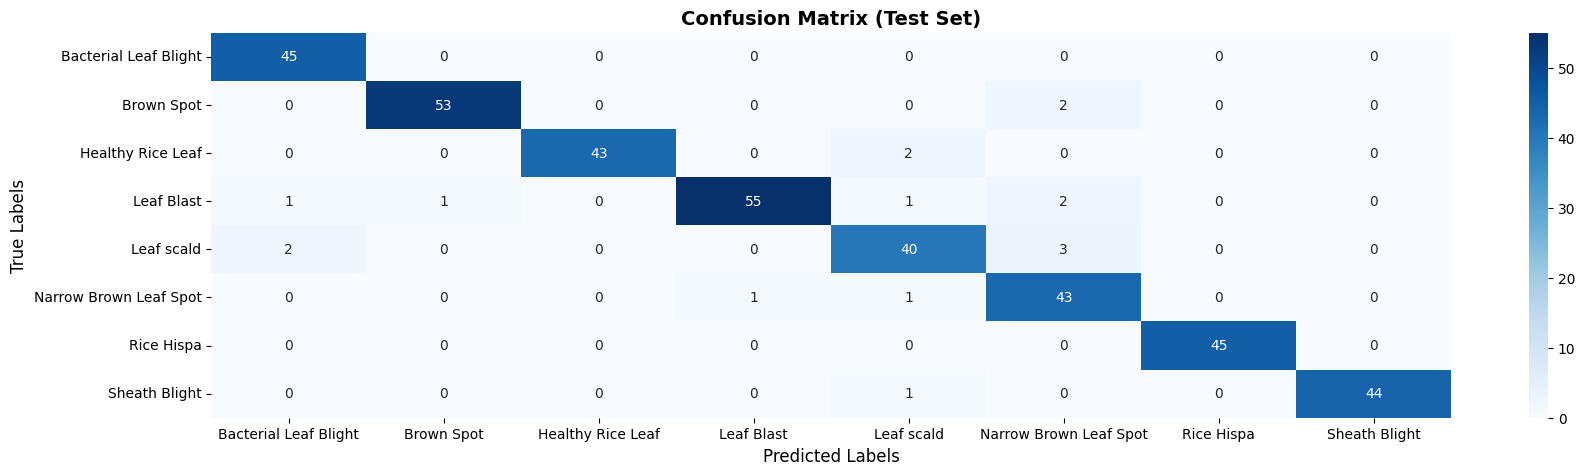

<Figure size 2000x500 with 0 Axes>

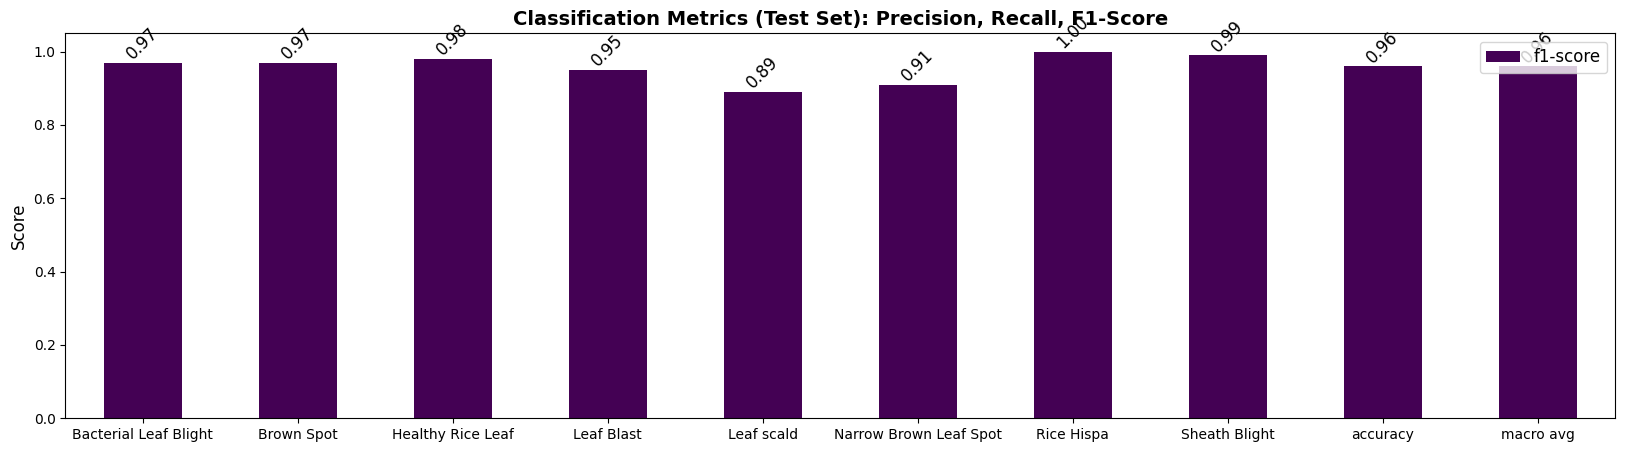

In [22]:
# ============
# DaViT-Tiny •
# ============
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader
from torchvision import transforms
import timm


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


TEST_ROOT = "/content/rice-leaf-disease-dataset/test"
test_dataset = RiceLeafDataset(root_dir=TEST_ROOT, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


model = timm.create_model(
    'davit_tiny',
    pretrained=False,
    drop_rate=0.20,
    drop_path_rate=0.10
)


if hasattr(model, 'reset_classifier'):
    model.reset_classifier(num_classes=8)
else:
    in_feats = model.head.in_features
    model.head = torch.nn.Linear(in_feats, 8)

model = model.cuda()


model.load_state_dict(torch.load("/content/drive/MyDrive/best_model_davit_tiny.pth"))
model.eval()
print("✅ Loaded best DaViT-Tiny weights successfully.")


def evaluate_model(model, dataloader):
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())


    classes = [
        'Bacterial Leaf Blight','Brown Spot','Healthy Rice Leaf','Leaf Blast',
        'Leaf scald','Narrow Brown Leaf Spot','Rice Hispa','Sheath Blight'
    ]


    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(2)


    report_df[['precision', 'recall']] = report_df[['precision', 'recall']].astype(object)
    if 'accuracy' in report_df.index:
        report_df.loc['accuracy', ['precision', 'recall']] = ''

    disease_rows = report_df.iloc[:-3]
    summary_rows = report_df.iloc[-3:]

    print("\nClassification Report:\n")
    print(disease_rows.to_string())
    print("\n")
    print(summary_rows.to_string())


    plt.figure(figsize=(20, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.show()


    metrics = report_df[['precision', 'recall', 'f1-score']].iloc[:-1]
    plt.figure(figsize=(20, 5))
    ax = metrics.plot(kind='bar', figsize=(20, 5), colormap='viridis')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=12, rotation=45)
    plt.title('Classification Metrics (Test Set): Precision, Recall, F1-Score', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()


evaluate_model(model, test_loader)


/tmp/ipykernel_2090/1388275040.py:176: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Epoch 1/35


  0%|          | 0/163 [00:00<?, ?it/s]/tmp/ipykernel_2090/1388275040.py:197: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
  0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_2090/1388275040.py:223: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 12/12 [00:03<00:00,  3.13it/s]


Train Loss: 1.5561 | Acc: 0.5525
Val   Loss: 2.0647 | Acc: 0.2344

Epoch 2/35


100%|██████████| 12/12 [00:04<00:00,  2.55it/s]


...

Train Loss: 0.4026 | Acc: 0.9996
Val   Loss: 0.4677 | Acc: 0.9688

Epoch 20/35


100%|██████████| 12/12 [00:03<00:00,  3.07it/s]


Train Loss: 0.4025 | Acc: 0.9992
Val   Loss: 0.4663 | Acc: 0.9688

Epoch 21/35


100%|██████████| 12/12 [00:04<00:00,  2.78it/s]


Train Loss: 0.4017 | Acc: 0.9992
Val   Loss: 0.4662 | Acc: 0.9661
Early stopping triggered.

 Best EMA+TTA Val Acc: 0.9766


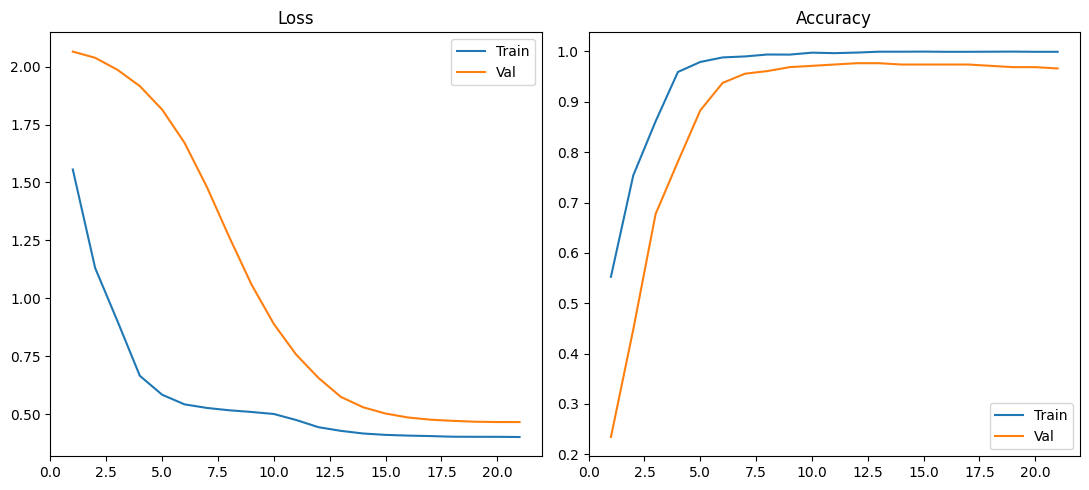

In [23]:
# ====== Advanced Adaptive-Attention Hybrid Tri-Backbone ======
# Improvements: Native 224x224 resolution, Heavy Augmentations, Adaptive Softmax Attention Fusion

import math, copy, os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import timm
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision import transforms
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True

NUM_CLASSES = 8
BATCH_SIZE  = 32

#  (Augmentations for better generalization)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = RiceLeafDataset(root_dir="/content/augmented_train", transform=train_transform)
val_dataset   = RiceLeafDataset(root_dir="/content/rice-leaf-disease-dataset/val", transform=val_transform)

dataloaders = {
    "train": DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True),
    "val":   DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
}

class EMA:
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval().requires_grad_(False)
        self.decay = decay
    @torch.no_grad()
    def update(self, model):
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if k in msd and v.dtype.is_floating_point:
                v.copy_(v * self.decay + msd[k].detach() * (1.0 - self.decay))

class GAP(nn.Module):
    def __init__(self): super().__init__(); self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        return self.pool(x).squeeze(-1).squeeze(-1) if x.ndim==4 else x

def build_efficientnet_b0_feat():
    b0 = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    in_feats = b0.classifier[1].in_features
    b0.classifier = nn.Identity()
    return b0, in_feats

def build_convnext_tiny_feat():
    cnx = timm.create_model("convnext_tiny.in12k_ft_in1k", pretrained=True)
    feat_dim = cnx.head.fc.in_features
    cnx.head.fc = nn.Identity()
    return cnx, feat_dim

def build_davit_tiny_feat():
    dav = timm.create_model("davit_tiny", pretrained=True)
    head_in = getattr(getattr(dav, "head", None), "in_features", None)
    dav.head = nn.Identity()
    return dav, head_in


class AdaptiveTriFusion(nn.Module):
    def __init__(self, proj_dim=512):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(proj_dim * 3, 256),
            nn.GELU(),
            nn.Linear(256, 3),
            nn.Softmax(dim=1)
        )

    def forward(self, b0p, cnxp, davp):
        cat_feats = torch.cat([b0p, cnxp, davp], dim=1) # (B, proj_dim*3)
        weights = self.attn(cat_feats) # (B, 3)

        w0 = weights[:, 0:1]
        w1 = weights[:, 1:2]
        w2 = weights[:, 2:3]

        fused = w0 * b0p + w1 * cnxp + w2 * davp # Adaptive weighted sum
        return fused, cat_feats

class HybridTriBackbone(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, proj_dim=512, drop=0.2):
        super().__init__()
        self.b0,  self.b0_dim  = build_efficientnet_b0_feat()
        self.cnx, self.cnx_dim = build_convnext_tiny_feat()
        self.dav, self.dav_dim = build_davit_tiny_feat()
        self.gap = GAP()

        self.proj_b0  = nn.Sequential(nn.Linear(self.b0_dim,  proj_dim), nn.GELU(), nn.Dropout(drop))
        self.proj_cnx = nn.Sequential(nn.Linear(self.cnx_dim, proj_dim), nn.GELU(), nn.Dropout(drop))
        self.proj_dav = nn.Sequential(nn.Linear(self.dav_dim, proj_dim), nn.GELU(), nn.Dropout(drop))

        self.fusion_gate = AdaptiveTriFusion(proj_dim=proj_dim)

        self.fuser = nn.Sequential(
            nn.BatchNorm1d(proj_dim * 4),
            nn.Linear(proj_dim * 4, 512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

        self.aux_eff = nn.Linear(proj_dim, num_classes)
        self.aux_cnx = nn.Linear(proj_dim, num_classes)
        self.aux_dav = nn.Linear(proj_dim, num_classes)

    def forward_backbone_feats(self, x):
        b0f = self.b0.features(x)
        b0p = self.proj_b0(self.gap(b0f))

        cnxf = self.cnx.forward_features(x)
        cnxp = self.proj_cnx(self.gap(cnxf))

        davf = self.dav.forward_features(x)
        if davf.ndim == 4: davf = self.gap(davf)
        davp = self.proj_dav(davf)
        return b0p, cnxp, davp

    def forward(self, x):
        b0p, cnxp, davp = self.forward_backbone_feats(x)

        # Adaptive attention fusion
        fused_vec, cat_feats = self.fusion_gate(b0p, cnxp, davp)

        # Main Logits calculation
        logits = self.fuser(torch.cat([fused_vec, cat_feats], dim=1))

        return logits, self.aux_eff(b0p), self.aux_cnx(cnxp), self.aux_dav(davp)

def build_loss():
    return nn.CrossEntropyLoss(label_smoothing=0.08)

def build_optimizer(model, base_lr=1.5e-4, wd=1e-2):
    return torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=wd)

def build_scheduler(optimizer, num_epochs=35, warmup=3):
    def lr_lambda(epoch):
        if epoch < warmup:
            return float(epoch + 1) / float(max(1, warmup))
        prog = (epoch - warmup) / float(max(1, num_epochs - warmup))
        return 0.1 + 0.9 * 0.5 * (1.0 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

@torch.no_grad()
def tta_logits(model, x):
    y1 = model(x)[0]
    y2 = model(torch.flip(x, dims=[3]))[0]
    return (y1 + y2) * 0.5

def train_hybrid(dataloaders, num_epochs=35, patience=9, freeze_epochs=2):
    model = HybridTriBackbone().to(device)
    criterion = build_loss()
    optimizer = build_optimizer(model)
    scheduler = build_scheduler(optimizer, num_epochs=num_epochs, warmup=3)
    ema = EMA(model, decay=0.999)
    scaler = GradScaler()

    def set_backbones_requires_grad(flag: bool):
        for m in [model.b0, model.cnx, model.dav]:
            for p in m.parameters():
                p.requires_grad_(flag)
    set_backbones_requires_grad(False)

    best_acc, es = 0.0, 0
    tr_losses, va_losses, tr_accs, va_accs = [], [], [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        if epoch == freeze_epochs:
            set_backbones_requires_grad(True)

        model.train()
        run_loss, corrects, seen = 0.0, 0, 0
        for imgs, labels in tqdm(dataloaders["train"]):
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                logits, aux_e, aux_c, aux_d = model(imgs)
                loss_main = criterion(logits, labels)
                # 85% Main Loss, 5% each aux loss
                loss = 0.85*loss_main + 0.05*criterion(aux_d, labels) + 0.05*criterion(aux_c, labels) + 0.05*criterion(aux_e, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            ema.update(model)

            run_loss += loss.item() * imgs.size(0)
            corrects += (logits.argmax(1) == labels).sum().item()
            seen += imgs.size(0)

        train_loss = run_loss / max(1, seen)
        train_acc  = corrects / max(1, seen)
        tr_losses.append(train_loss); tr_accs.append(train_acc)
        scheduler.step()

        model.eval(); ema.ema.eval()
        v_loss, v_corr, v_seen = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in tqdm(dataloaders["val"]):
                imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                with autocast():
                    logits_tta = tta_logits(ema.ema, imgs)
                    loss = criterion(logits_tta, labels)
                v_loss += loss.item() * imgs.size(0)
                v_corr += (logits_tta.argmax(1) == labels).sum().item()
                v_seen += imgs.size(0)

        val_loss = v_loss / max(1, v_seen)
        val_acc  = v_corr / max(1, v_seen)
        va_losses.append(val_loss); va_accs.append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc, es = val_acc, 0
            torch.save(ema.ema.state_dict(), "/content/drive/MyDrive/best_hybrid_efficientnet_convnext_davit.pth")
        else:
            es += 1
            if es >= patience:
                print("Early stopping triggered.")
                break

    print(f"\n Best EMA+TTA Val Acc: {best_acc:.4f}")
    plot_curves(tr_losses, va_losses, tr_accs, va_accs)

def plot_curves(tr_losses, va_losses, tr_accs, va_accs):
    xs = range(1, len(tr_losses)+1)
    plt.figure(figsize=(11,5))
    plt.subplot(1,2,1); plt.plot(xs, tr_losses, label="Train"); plt.plot(xs, va_losses, label="Val"); plt.title("Loss"); plt.legend()
    plt.subplot(1,2,2); plt.plot(xs, tr_accs, label="Train"); plt.plot(xs, va_accs, label="Val"); plt.title("Accuracy"); plt.legend()
    plt.tight_layout(); plt.show()

# Run Advanced Hybrid Training
train_hybrid(dataloaders, num_epochs=35, patience=9, freeze_epochs=2)

🔹 Loading best saved hybrid model...


100%|██████████| 12/12 [00:11<00:00,  1.05it/s]



Confusion Matrix:
 [[43  0  0  2  0  0  0  0]
 [ 0 53  0  0  0  1  0  0]
 [ 0  0 44  0  1  0  0  0]
 [ 0  0  0 58  2  0  0  0]
 [ 1  0  0  1 43  0  0  0]
 [ 0  0  0  0  0 45  0  0]
 [ 0  0  0  0  0  0 44  1]
 [ 0  0  0  0  0  0  0 45]]

Classification Report:
                         precision    recall  f1-score   support

 Bacterial Leaf Blight       0.98      0.96      0.97        45
            Brown Spot       1.00      0.98      0.99        54
     Healthy Rice Leaf       1.00      0.98      0.99        45
            Leaf Blast       0.95      0.97      0.96        60
            Leaf scald       0.93      0.96      0.95        45
Narrow Brown Leaf Spot       0.98      1.00      0.99        45
            Rice Hispa       1.00      0.98      0.99        45
         Sheath Blight       0.98      1.00      0.99        45

              accuracy                           0.98       384
             macro avg       0.98      0.98      0.98       384
          weighted avg       0.9

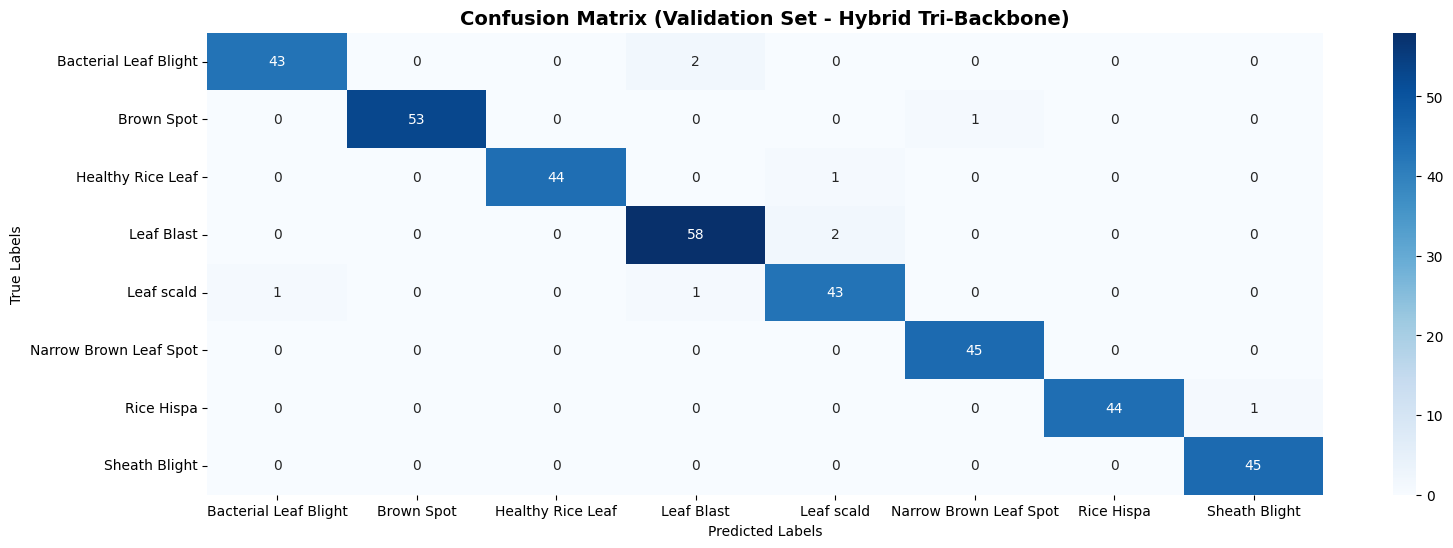

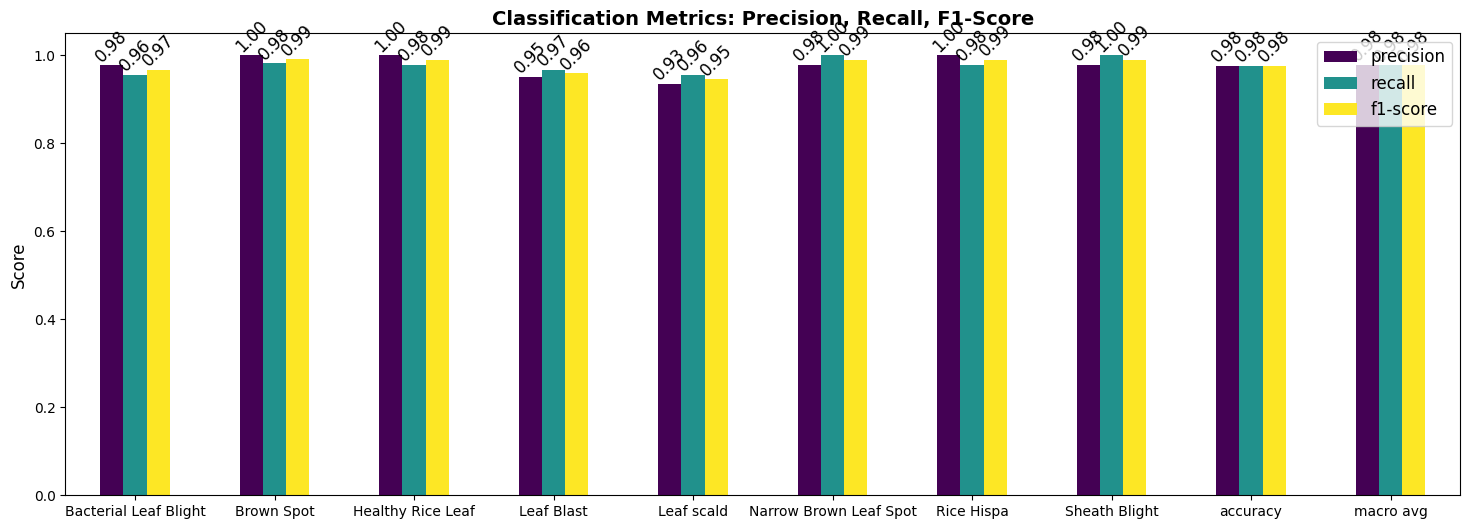

In [24]:
# ==========================================================
# EVALUATION FOR HYBRID TRI-BACKBONE (EffB0 → ConvNeXt → DaViT)
# ==========================================================

import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

# TTA (Test-Time Augmentation)
@torch.no_grad()
def tta_logits(model, x):
    y1 = model(x)[0]
    y2 = model(torch.flip(x, dims=[3]))[0]
    return (y1 + y2) * 0.5


def evaluate_model(dataloader):
    print("🔹 Loading best saved hybrid model...")

    model = HybridTriBackbone(num_classes=8).to(device)

    state_dict = torch.load("/content/drive/MyDrive/best_hybrid_efficientnet_convnext_davit.pth", map_location=device)
    model.load_state_dict(state_dict, strict=True)

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader):
            imgs, labels = imgs.to(device), labels.to(device)

            # TTA
            logits = tta_logits(model, imgs)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    classes = ['Bacterial Leaf Blight','Brown Spot','Healthy Rice Leaf','Leaf Blast',
               'Leaf scald','Narrow Brown Leaf Spot','Rice Hispa','Sheath Blight']

    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=classes))

    # Confusion Matrix Heatmap
    plt.figure(figsize=(18,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix (Validation Set - Hybrid Tri-Backbone)", fontsize=14, fontweight="bold")
    plt.xlabel("Predicted Labels"); plt.ylabel("True Labels")
    plt.show()

    # Classification Metrics Bar Chart
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    metrics = report_df[['precision','recall','f1-score']].iloc[:-1]
    ax = metrics.plot(kind='bar', figsize=(18,6), colormap='viridis')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=12, rotation=45)
    plt.title('Classification Metrics: Precision, Recall, F1-Score', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(loc='upper right', fontsize=12)
    plt.show()


evaluate_model(dataloaders['val'])

In [25]:
import os

files_to_check = [
    "/content/drive/MyDrive/best_model_efficientnet_b0.pth",
    "/content/drive/MyDrive/best_model_swin_tiny.pth",
    "/content/drive/MyDrive/best_model_convnext_tiny_timm_ema_smooth.pth",
    "/content/drive/MyDrive/best_model_davit_tiny.pth",
    "/content/drive/MyDrive/best_hybrid_efficientnet_convnext_davit.pth",
]

for f in files_to_check:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024*1024)
        print(f"✅ true ({size_mb:.1f} MB): {f}")
    else:
        print(f"❌ fulse: {f}")

✅ true (15.6 MB): /content/drive/MyDrive/best_model_efficientnet_b0.pth
✅ true (105.1 MB): /content/drive/MyDrive/best_model_swin_tiny.pth
✅ true (106.2 MB): /content/drive/MyDrive/best_model_convnext_tiny_timm_ema_smooth.pth
✅ true (105.4 MB): /content/drive/MyDrive/best_model_davit_tiny.pth
✅ true (238.2 MB): /content/drive/MyDrive/best_hybrid_efficientnet_convnext_davit.pth


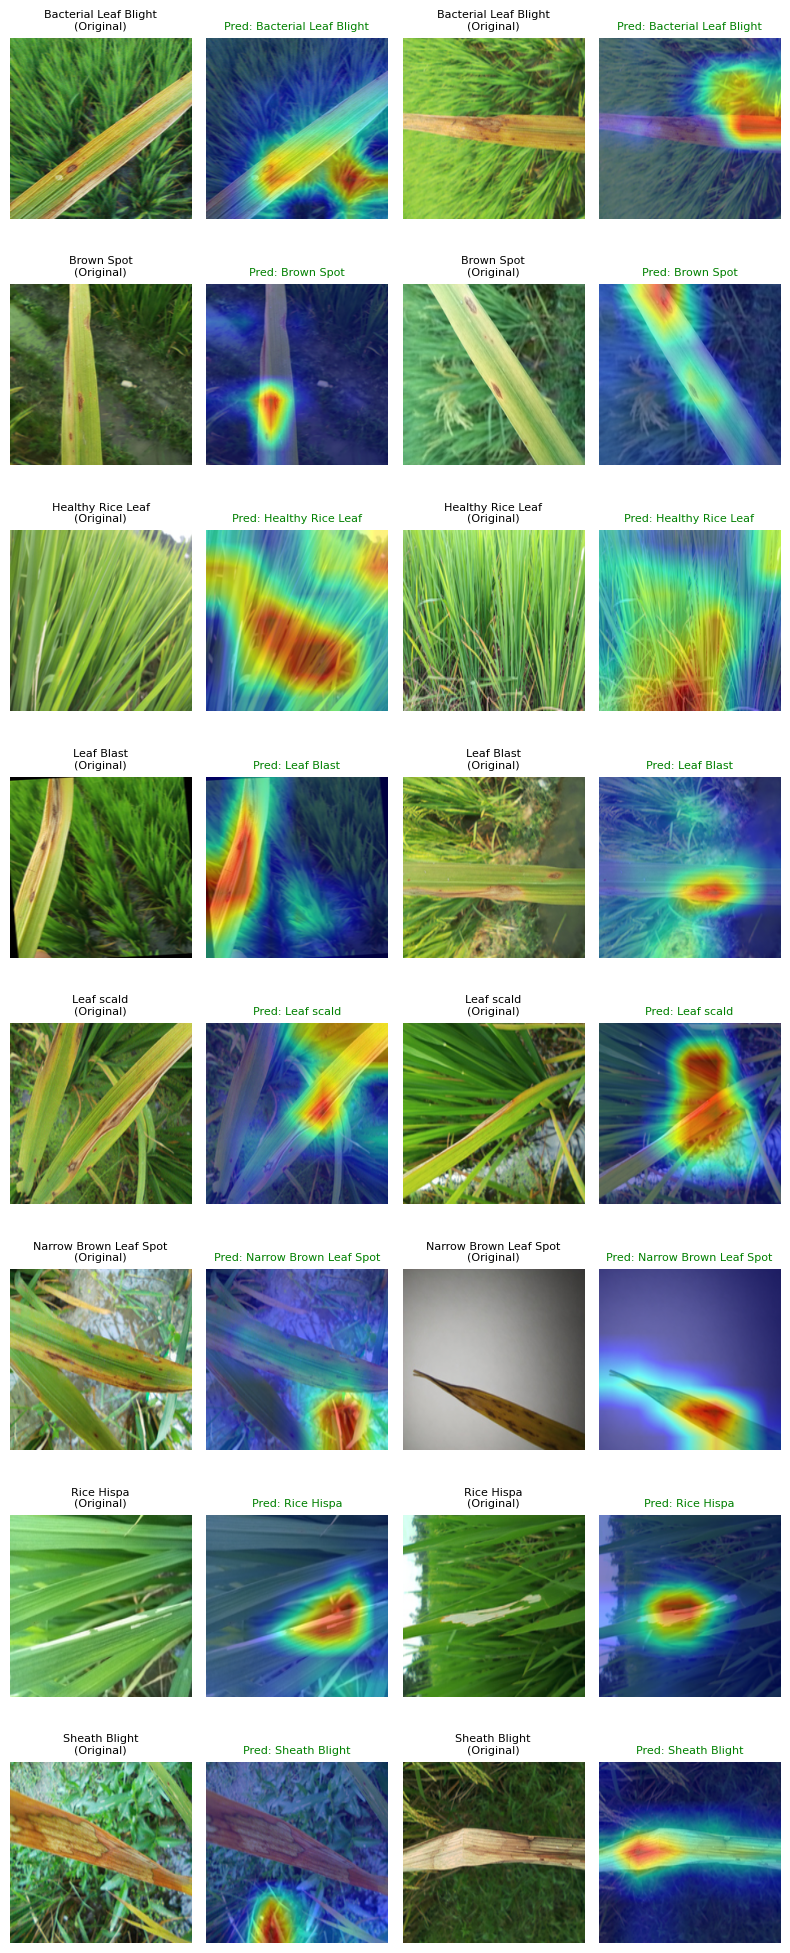

Grad-CAM grid saved: gradcam_hybrid_results.png


In [26]:
# ==========================================================
# GRAD-CAM VISUALIZATION FOR HYBRID TRI-BACKBONE MODEL
# ==========================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = "cuda" if torch.cuda.is_available() else "cpu"

# Class names in the same order used throughout training
classes = ['Bacterial Leaf Blight','Brown Spot','Healthy Rice Leaf','Leaf Blast',
           'Leaf scald','Narrow Brown Leaf Spot','Rice Hispa','Sheath Blight']

# ---- 1. Load the trained hybrid model ----
model = HybridTriBackbone(num_classes=8).to(device)
state_dict = torch.load("/content/drive/MyDrive/best_hybrid_efficientnet_convnext_davit.pth", map_location=device)
model.load_state_dict(state_dict, strict=True)
model.eval()

# ---- 2. Wrapper: model.forward() returns 4 outputs (logits, aux_e, aux_c, aux_d)
#         but Grad-CAM needs a model that returns only the main logits ----
class GradCAMWrapper(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
    def forward(self, x):
        logits, _, _, _ = self.base_model(x)
        return logits

cam_model = GradCAMWrapper(model).to(device)
cam_model.eval()

# ---- 3. Target layer: last conv feature layer of the EfficientNetB0 branch ----
target_layers = [model.b0.features[-1]]

cam = GradCAM(model=cam_model, target_layers=target_layers)

# ---- 4. Same preprocessing/transform used for the hybrid model (224x224) ----
gradcam_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

TEST_ROOT = "/content/rice-leaf-disease-dataset/test"
gradcam_dataset = RiceLeafDataset(root_dir=TEST_ROOT, transform=gradcam_transform)

# ---- 5. Undo normalization so the image can be displayed correctly ----
def unnormalize(img_tensor):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    return np.clip(img, 0, 1)

# ---- 6. Show Grad-CAM for a few samples per class in a grid ----
def show_gradcam_grid(dataset, num_per_class=2, save_path="gradcam_hybrid_results.png"):
    # group image indices by class label
    class_to_indices = {i: [] for i in range(8)}
    for idx, label in enumerate(dataset.labels):
        class_to_indices[label].append(idx)

    fig, axes = plt.subplots(8, num_per_class * 2, figsize=(num_per_class * 4, 20))

    for cls in range(8):
        picks = class_to_indices[cls][:num_per_class]
        for j, idx in enumerate(picks):
            img_tensor, true_label = dataset[idx]
            input_tensor = img_tensor.unsqueeze(0).to(device)

            # get model's prediction for this image
            with torch.no_grad():
                logits, _, _, _ = model(input_tensor)
                pred_class = logits.argmax(dim=1).item()

            # generate Grad-CAM heatmap for the predicted class
            targets = [ClassifierOutputTarget(pred_class)]
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

            rgb_img = unnormalize(img_tensor)
            visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

            # left column: original image
            ax_orig = axes[cls, j * 2]
            ax_orig.imshow(rgb_img)
            ax_orig.set_title(f"{classes[cls]}\n(Original)", fontsize=8)
            ax_orig.axis('off')

            # right column: Grad-CAM heatmap overlay
            ax_cam = axes[cls, j * 2 + 1]
            ax_cam.imshow(visualization)
            correct = (pred_class == true_label)
            ax_cam.set_title(f"Pred: {classes[pred_class]}", fontsize=8,
                              color=("green" if correct else "red"))
            ax_cam.axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Grad-CAM grid saved: {save_path}")

show_gradcam_grid(gradcam_dataset, num_per_class=2)

In [28]:
!cp gradcam_hybrid_results.png /content/drive/MyDrive/

===== FINAL MODEL COMPARISON (All Baselines + Hybrid) =====
            Model  Accuracy (%)
Hybrid (Proposed)         97.66
       DaViT-Tiny         97.14
    ConvNeXt-Tiny         96.09
   EfficientNetB0         95.83
 Swin Transformer         94.53


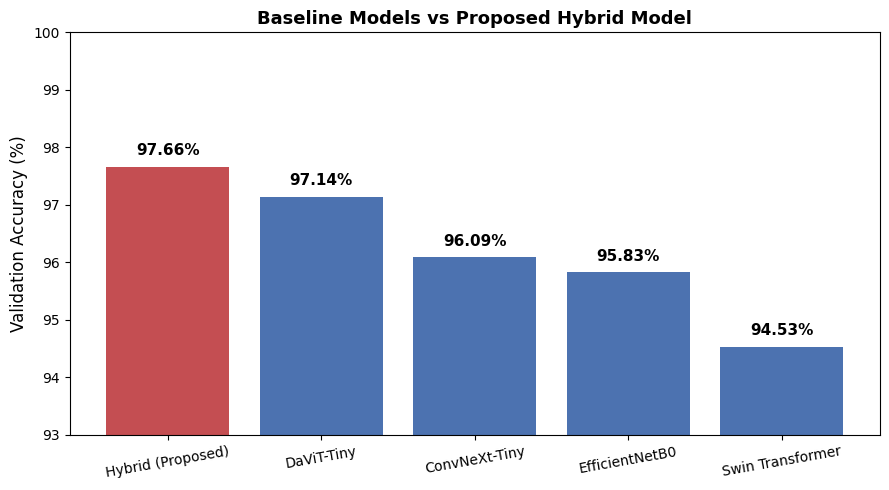


 Best performing model: Hybrid (Proposed) with 97.66% accuracy


In [32]:
# FINAL
import matplotlib.pyplot as plt
import pandas as pd

model_accuracies = {
    "Swin Transformer":  94.53,
    "EfficientNetB0":    95.83,
    "ConvNeXt-Tiny":     96.09,
    "DaViT-Tiny":        97.14,
    "Hybrid (Proposed)": 97.66,
}

summary_df = pd.DataFrame(list(model_accuracies.items()), columns=["Model", "Accuracy (%)"])
summary_df = summary_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

print("===== FINAL MODEL COMPARISON (All Baselines + Hybrid) =====")
print(summary_df.to_string(index=False))

colors = ["#4C72B0" if m != "Hybrid (Proposed)" else "#C44E52" for m in summary_df["Model"]]

plt.figure(figsize=(9, 5))
bars = plt.bar(summary_df["Model"], summary_df["Accuracy (%)"], color=colors)

for bar, acc in zip(bars, summary_df["Accuracy (%)"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
              f"{acc:.2f}%", ha='center', fontsize=11, fontweight='bold')

plt.ylim(93, 100)
plt.ylabel("Validation Accuracy (%)", fontsize=12)
plt.title("Baseline Models vs Proposed Hybrid Model", fontsize=13, fontweight='bold')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("final_model_comparison.png", dpi=150, bbox_inches='tight')

# Drive
plt.savefig("/content/drive/MyDrive/final_model_comparison.png", dpi=150, bbox_inches='tight')

plt.show()

print(f"\n Best performing model: {summary_df.iloc[0]['Model']} with {summary_df.iloc[0]['Accuracy (%)']:.2f}% accuracy")

## 0. Common Setup — Trained Model

**0. Common Setup — Load Trained Model

Why needed: Loads the correct trained model before each experiment and avoids depending on previous cells.

In [34]:
# COMMON SETUP: Reload the trained hybrid model reliably
# (does not depend on any earlier cell's `model` variable — loads fresh here)

import os, torch

classes = ['Bacterial Leaf Blight','Brown Spot','Healthy Rice Leaf','Leaf Blast',
           'Leaf scald','Narrow Brown Leaf Spot','Rice Hispa','Sheath Blight']

WEIGHT_PATH = "/content/drive/MyDrive/best_hybrid_efficientnet_convnext_davit.pth"  # file created during training

assert os.path.exists(WEIGHT_PATH), (
    "❌ Weight file not found! "
)

model = HybridTriBackbone(num_classes=8).to(device)
model.load_state_dict(torch.load(WEIGHT_PATH, map_location=device), strict=True)
model.eval()
print(" Trained hybrid model loaded successfully")

 Trained hybrid model loaded successfully


## 1️ Cross-Dataset / External Validation

What it does: Tests the trained model on a completely different rice leaf dataset — one it has never seen during training.

Why it was added: Good accuracy on the same dataset's train/test split still leaves a question open — has the model learned the actual disease patterns, or just memorized that dataset's image style (camera, lighting, background)? Testing on a new, unseen dataset gives the real answer — it's the strongest way to prove "generalization," and none of your reference papers did this.

In [43]:
import os, shutil

source_root = "/content/drive/MyDrive/7k/thesis-id-062&063(7k)/Rice leaf disease"
clean_folder = "/content/drive/MyDrive/7k_clean_external"

for cls in classes:
    os.makedirs(os.path.join(clean_folder, cls), exist_ok=True)

copied = 0
skipped_duplicate = 0

for cls in classes:
    class_folder = os.path.join(source_root, cls)
    if not os.path.isdir(class_folder):
        print(f"⚠️ Folder not found, skipping: {class_folder}")
        continue

    for fname in os.listdir(class_folder):
        fpath = os.path.join(class_folder, fname)
        try:
            with open(fpath, "rb") as f:
                h = hashlib.md5(f.read()).hexdigest()
        except Exception:
            continue

        if h in original_hashes:
            skipped_duplicate += 1
            continue

        dest = os.path.join(clean_folder, cls, fname)
        shutil.copy2(fpath, dest)
        copied += 1

print(f"✅ Duplicate images skipped: {skipped_duplicate}")
print(f"✅ Clean (non-duplicate) images copied: {copied}")
print(f"📁 Clean external dataset saved at: {clean_folder}")

✅ Duplicate images skipped: 2704
✅ Clean (non-duplicate) images copied: 4738
📁 Clean external dataset saved at: /content/drive/MyDrive/7k_clean_external


Contents inside the new dataset folder: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight']
Total number of external test images: 4738

🔹 Testing the trained hybrid model on the external dataset...
🔹 Loading best saved hybrid model...


100%|██████████| 149/149 [04:43<00:00,  1.90s/it]



Confusion Matrix:
 [[455   6   0  19  16  13   0   3]
 [  0 715   7   5   0   6   0   0]
 [  0   1 408   0   2   0   0   0]
 [  1  15   0 807   6  16   0   0]
 [  0   1   0   6 592  21   0   0]
 [  1  21   0   7   3 286   0   6]
 [  2   0   0   0   0   0 558   0]
 [  1   0   0   0   0   0   0 732]]

Classification Report:
                         precision    recall  f1-score   support

 Bacterial Leaf Blight       0.99      0.89      0.94       512
            Brown Spot       0.94      0.98      0.96       733
     Healthy Rice Leaf       0.98      0.99      0.99       411
            Leaf Blast       0.96      0.96      0.96       845
            Leaf scald       0.96      0.95      0.96       620
Narrow Brown Leaf Spot       0.84      0.88      0.86       324
            Rice Hispa       1.00      1.00      1.00       560
         Sheath Blight       0.99      1.00      0.99       733

              accuracy                           0.96      4738
             macro avg       0.9

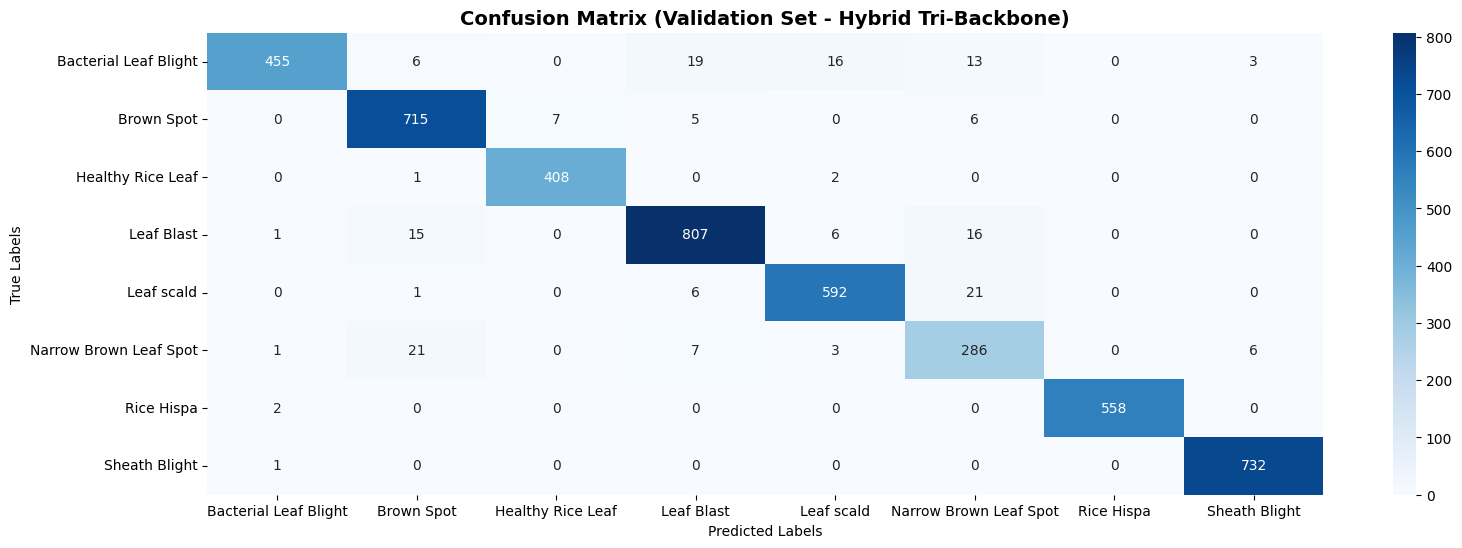

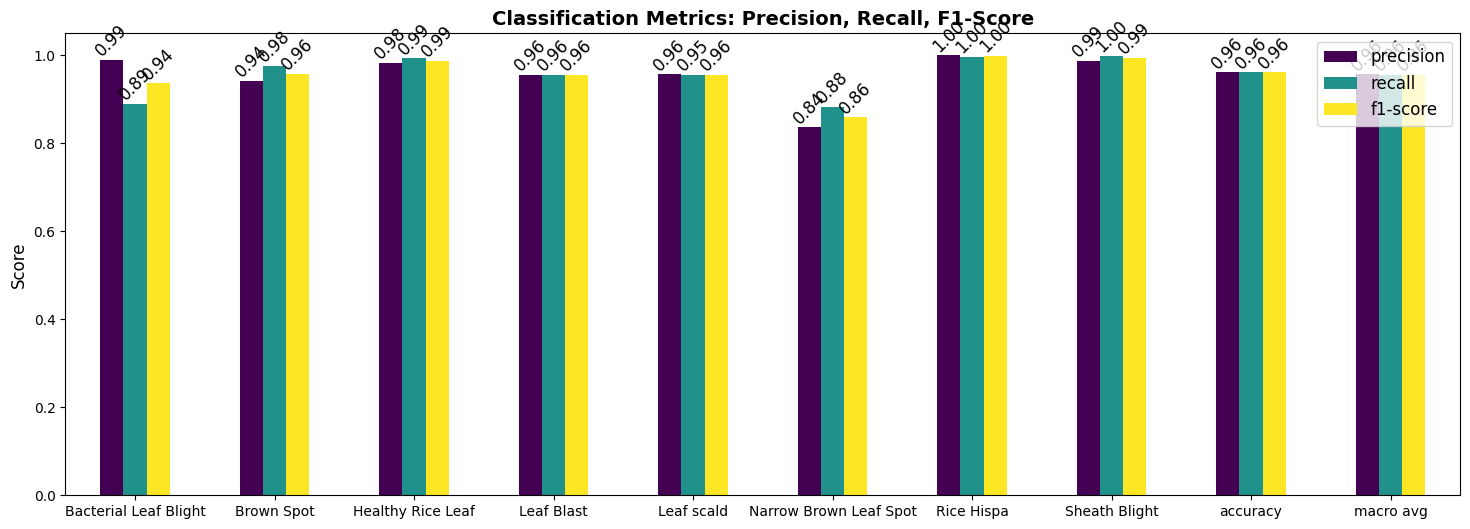

In [44]:
# 1) CROSS-DATASET / EXTERNAL VALIDATION

from torch.utils.data import DataLoader

# Path to the new (external/unseen) dataset
new_dataset_path = "/content/drive/MyDrive/7k_clean_external"

print("Contents inside the new dataset folder:", os.listdir(new_dataset_path))

external_dataset = RiceLeafDataset(root_dir=new_dataset_path, transform=val_transform)
external_loader  = DataLoader(external_dataset, batch_size=32, shuffle=False)
print("Total number of external test images:", len(external_dataset))

print("\n🔹 Testing the trained hybrid model on the external dataset...")
evaluate_model(external_loader)   # reuses the evaluate_model(dataloader) function already defined earlier in the notebook

🔹 Running predictions on the original (training) dataset...
🔹 Running predictions on the external (new) dataset...

===== OVERALL ACCURACY COMPARISON =====
                    Dataset  Number of Images  Accuracy (%)
Original (Training Dataset)               384         97.66
     External (New Dataset)              4738         96.10

===== PER-CLASS F1-SCORE COMPARISON (Original vs External) =====
         Disease Class  Original F1-score  External F1-score  Difference
 Bacterial Leaf Blight              96.63              93.62        3.01
            Brown Spot              99.07              95.84        3.23
     Healthy Rice Leaf              98.88              98.79        0.09
            Leaf Blast              95.87              95.56        0.31
            Leaf scald              94.51              95.56       -1.05
Narrow Brown Leaf Spot              98.90              85.89       13.01
            Rice Hispa              98.88              99.82       -0.94
         Sheat

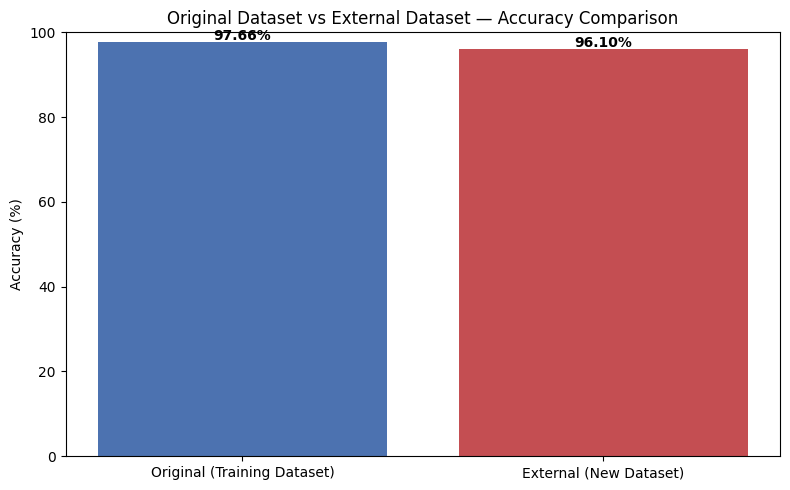

In [45]:
#  ORIGINAL vs EXTERNAL DATASET — COMPARISON TABLE
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

def get_predictions(dataloader):
    """Run the hybrid model on a dataloader and return (y_true, y_pred)"""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            logits = tta_logits(model, imgs)
            preds = torch.argmax(logits, dim=1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
    return np.array(y_true), np.array(y_pred)

# ---- 1. Get predictions on both datasets ----
print("🔹 Running predictions on the original (training) dataset...")
y_true_orig, y_pred_orig = get_predictions(dataloaders['val'])

print("🔹 Running predictions on the external (new) dataset...")
y_true_ext, y_pred_ext = get_predictions(external_loader)

# ---- 2. Overall accuracy comparison table ----
acc_orig = accuracy_score(y_true_orig, y_pred_orig) * 100
acc_ext  = accuracy_score(y_true_ext, y_pred_ext) * 100

overall_df = pd.DataFrame({
    "Dataset": ["Original (Training Dataset)", "External (New Dataset)"],
    "Number of Images": [len(y_true_orig), len(y_true_ext)],
    "Accuracy (%)": [round(acc_orig, 2), round(acc_ext, 2)]
})

print("\n===== OVERALL ACCURACY COMPARISON =====")
print(overall_df.to_string(index=False))

# ---- 3. Per-class (per-disease) comparison ----
report_orig = classification_report(y_true_orig, y_pred_orig, target_names=classes, output_dict=True)
report_ext  = classification_report(y_true_ext, y_pred_ext, target_names=classes, output_dict=True)

per_class_df = pd.DataFrame({
    "Disease Class": classes,
    "Original F1-score": [round(report_orig[c]["f1-score"]*100, 2) for c in classes],
    "External F1-score": [round(report_ext[c]["f1-score"]*100, 2) for c in classes],
})
per_class_df["Difference"] = (per_class_df["Original F1-score"] - per_class_df["External F1-score"]).round(2)

print("\n===== PER-CLASS F1-SCORE COMPARISON (Original vs External) =====")
print(per_class_df.to_string(index=False))

# ---- 4. Visualize with a bar chart ----
plt.figure(figsize=(8, 5))
plt.bar(overall_df["Dataset"], overall_df["Accuracy (%)"], color=["#4C72B0", "#C44E52"])
for i, acc in enumerate(overall_df["Accuracy (%)"]):
    plt.text(i, acc + 0.5, f"{acc:.2f}%", ha='center', fontweight='bold')
plt.ylabel("Accuracy (%)")
plt.title("Original Dataset vs External Dataset — Accuracy Comparison")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/original_vs_external_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 2️ Backbone Attention-Weight Analysis


Average importance given to each backbone, per disease class:

Bacterial Leaf Blight      EfficientNet=0.25   ConvNeXt=0.14   DaViT=0.61
Brown Spot                 EfficientNet=0.21   ConvNeXt=0.26   DaViT=0.53
Healthy Rice Leaf          EfficientNet=0.13   ConvNeXt=0.43   DaViT=0.43
Leaf Blast                 EfficientNet=0.30   ConvNeXt=0.30   DaViT=0.41
Leaf scald                 EfficientNet=0.38   ConvNeXt=0.13   DaViT=0.49
Narrow Brown Leaf Spot     EfficientNet=0.46   ConvNeXt=0.16   DaViT=0.38
Rice Hispa                 EfficientNet=0.31   ConvNeXt=0.31   DaViT=0.38
Sheath Blight              EfficientNet=0.35   ConvNeXt=0.17   DaViT=0.48


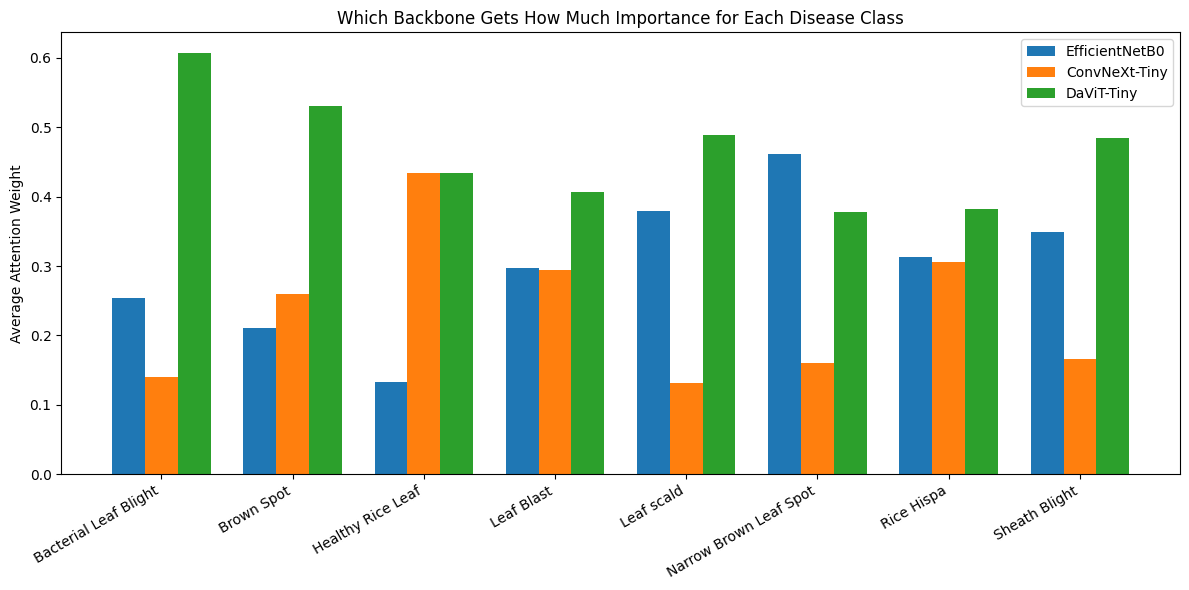

In [46]:
# 2) BACKBONE ATTENTION-WEIGHT ANALYSIS
import numpy as np
import matplotlib.pyplot as plt

all_weights = []
all_labels  = []

model.eval()
with torch.no_grad():
    for imgs, labels in dataloaders['val']:
        imgs = imgs.to(device)
        b0p, cnxp, davp = model.forward_backbone_feats(imgs)          # Features from the three backbones
        cat_feats = torch.cat([b0p, cnxp, davp], dim=1)
        weights = model.fusion_gate.attn(cat_feats)                    # (batch, 3) -> importance weight of each backbone
        all_weights.append(weights.cpu().numpy())
        all_labels.extend(labels.numpy())

all_weights = np.concatenate(all_weights)
all_labels  = np.array(all_labels)

print("Average importance given to each backbone, per disease class:\n")
avg_per_class = []
for i, cls in enumerate(classes):
    idx = all_labels == i
    avg_w = all_weights[idx].mean(axis=0)
    avg_per_class.append(avg_w)
    print(f"{cls:25s}  EfficientNet={avg_w[0]:.2f}   ConvNeXt={avg_w[1]:.2f}   DaViT={avg_w[2]:.2f}")

avg_per_class = np.array(avg_per_class)

# Plot the results
fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(classes))
width = 0.25
ax.bar(x - width, avg_per_class[:,0], width, label='EfficientNetB0')
ax.bar(x,          avg_per_class[:,1], width, label='ConvNeXt-Tiny')
ax.bar(x + width,  avg_per_class[:,2], width, label='DaViT-Tiny')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_ylabel('Average Attention Weight')
ax.set_title('Which Backbone Gets How Much Importance for Each Disease Class')
ax.legend()
plt.tight_layout()
plt.show()

## 3️ Efficiency / Inference-Time Benchmarking


In [47]:
# 3) EFFICIENCY / INFERENCE-TIME BENCHMARKING
import time

def benchmark_model(model, name, n_runs=50):
    total_params = sum(p.numel() for p in model.parameters())
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)

    # Warm-up runs (skip the first few so the GPU is properly ready)
    with torch.no_grad():
        for _ in range(5):
            _ = model(dummy_input)

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(dummy_input)
    if device == "cuda":
        torch.cuda.synchronize()

    avg_time_ms = (time.time() - start) / n_runs * 1000
    model_size_mb = total_params * 4 / (1024 ** 2)  # approximate size assuming float32

    print(f"{name}:")
    print(f"   Total Parameters     : {total_params/1e6:.2f} M")
    print(f"   Approximate Model Size : {model_size_mb:.2f} MB")
    print(f"   Inference Time       : {avg_time_ms:.2f} ms/image  (Device: {device})")
    return total_params, avg_time_ms

_ = benchmark_model(model, "Hybrid Tri-Backbone (Proposed)")

Hybrid Tri-Backbone (Proposed):
   Total Parameters     : 62.32 M
   Approximate Model Size : 237.75 MB
   Inference Time       : 102.91 ms/image  (Device: cuda)


Hybrid Tri-Backbone (Proposed):
   Total Parameters     : 62.32 M
   Approximate Model Size : 237.75 MB
   Inference Time       : 92.32 ms/image  (Device: cuda)
EfficientNetB0:
   Total Parameters     : 4.02 M
   Approximate Model Size : 15.33 MB
   Inference Time       : 52.97 ms/image  (Device: cuda)
Swin Transformer:
   Total Parameters     : 27.53 M
   Approximate Model Size : 105.00 MB
   Inference Time       : 31.03 ms/image  (Device: cuda)
ConvNeXt-Tiny:
   Total Parameters     : 27.83 M
   Approximate Model Size : 106.15 MB
   Inference Time       : 7.55 ms/image  (Device: cuda)
DaViT-Tiny:
   Total Parameters     : 27.60 M
   Approximate Model Size : 105.28 MB
   Inference Time       : 12.91 ms/image  (Device: cuda)

===== EFFICIENCY COMPARISON TABLE =====
                         Model  Parameters (M)  Inference Time (ms)
Hybrid Tri-Backbone (Proposed)       62.324479            92.323031
                EfficientNetB0        4.017796            52.965798
              Swin T

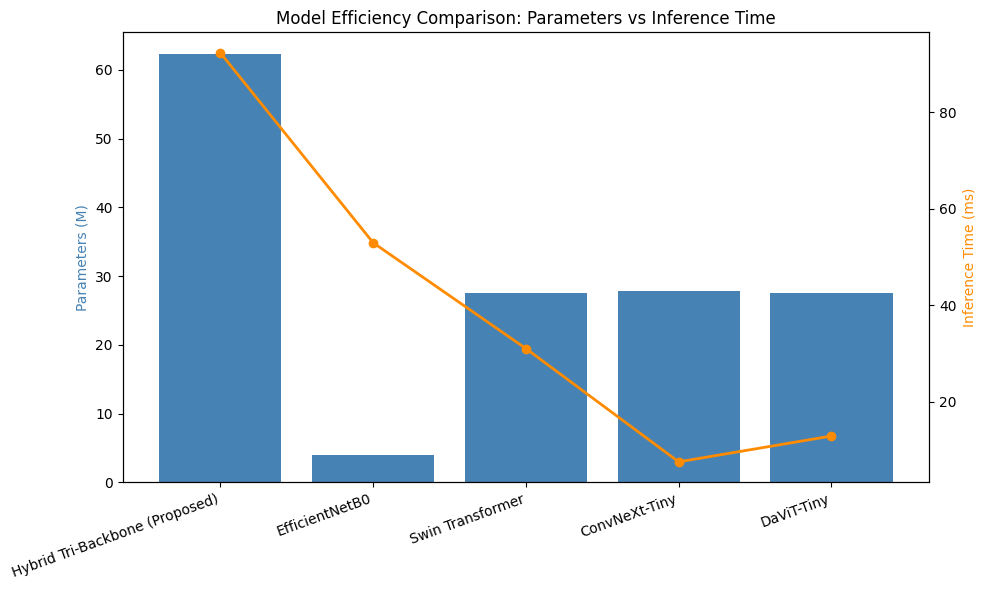

In [50]:

# 3B) EFFICIENCY COMPARISON — HYBRID vs ALL BASELINE MODELS
import os, time, timm
import torchvision.models as tvm
import matplotlib.pyplot as plt
import pandas as pd

drive_folder = "/content/drive/MyDrive"

def load_and_benchmark(arch_name, weight_filename, display_name, n_runs=50):
    weight_path = os.path.join(drive_folder, weight_filename)
    m = timm.create_model(arch_name, pretrained=False, num_classes=8).to(device)
    state_dict = torch.load(weight_path, map_location=device)
    try:
        m.load_state_dict(state_dict, strict=True)
    except Exception as e:
        print(f" strict=True failed for {display_name}, retrying with strict=False. Error: {e}")
        m.load_state_dict(state_dict, strict=False)
    m.eval()
    return benchmark_model(m, display_name, n_runs=n_runs)

def load_and_benchmark_torchvision_effnet(weight_filename, display_name, n_runs=50):
    weight_path = os.path.join(drive_folder, weight_filename)
    m = tvm.efficientnet_b0(weights=None)
    m.classifier[1] = torch.nn.Linear(m.classifier[1].in_features, 8)   # match your 8 classes
    m = m.to(device)
    state_dict = torch.load(weight_path, map_location=device)
    m.load_state_dict(state_dict, strict=True)
    m.eval()
    return benchmark_model(m, display_name, n_runs=n_runs)

results = {}

# Hybrid model — already defined as `model`
hybrid_params, hybrid_time = benchmark_model(model, "Hybrid Tri-Backbone (Proposed)")
results["Hybrid Tri-Backbone (Proposed)"] = (hybrid_params, hybrid_time)

# EfficientNetB0 — built with torchvision (matches how it was originally trained)
try:
    eff_params, eff_time = load_and_benchmark_torchvision_effnet(
        "best_model_efficientnet_b0.pth", "EfficientNetB0"
    )
    results["EfficientNetB0"] = (eff_params, eff_time)
except Exception as e:
    print(f" Could not benchmark EfficientNetB0: {e}")

# Remaining baselines — built with timm (loaded cleanly earlier, no changes needed)
baseline_configs = [
    ("swin_tiny_patch4_window7_224", "best_model_swin_tiny.pth",                     "Swin Transformer"),
    ("convnext_tiny",                "best_model_convnext_tiny_timm_ema_smooth.pth", "ConvNeXt-Tiny"),
    ("davit_tiny",                   "best_model_davit_tiny.pth",                    "DaViT-Tiny"),
]

for arch_name, weight_filename, display_name in baseline_configs:
    try:
        params, avg_time = load_and_benchmark(arch_name, weight_filename, display_name)
        results[display_name] = (params, avg_time)
    except Exception as e:
        print(f" Could not benchmark {display_name}: {e}")

# ---- Comparison table ----
df = pd.DataFrame([
    {"Model": name, "Parameters (M)": p/1e6, "Inference Time (ms)": t}
    for name, (p, t) in results.items()
])
print("\n===== EFFICIENCY COMPARISON TABLE =====")
print(df.to_string(index=False))

# ---- Bar + line chart ----
fig, ax1 = plt.subplots(figsize=(10,6))
x = range(len(df))
ax1.bar(x, df["Parameters (M)"], color="steelblue", label="Parameters (M)")
ax1.set_ylabel("Parameters (M)", color="steelblue")
ax1.set_xticks(x)
ax1.set_xticklabels(df["Model"], rotation=20, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, df["Inference Time (ms)"], color="darkorange", marker="o", linewidth=2, label="Inference Time (ms)")
ax2.set_ylabel("Inference Time (ms)", color="darkorange")

plt.title("Model Efficiency Comparison: Parameters vs Inference Time")
fig.tight_layout()
plt.savefig("/content/drive/MyDrive/efficiency_comparison.png")
plt.show()

## 4️ Robustness Testing



================ Original (No Change) ================
🔹 Loading best saved hybrid model...


100%|██████████| 12/12 [00:11<00:00,  1.06it/s]



Confusion Matrix:
 [[43  0  0  2  0  0  0  0]
 [ 0 53  0  0  0  1  0  0]
 [ 0  0 44  0  1  0  0  0]
 [ 0  0  0 58  2  0  0  0]
 [ 1  0  0  1 43  0  0  0]
 [ 0  0  0  0  0 45  0  0]
 [ 0  0  0  0  0  0 44  1]
 [ 0  0  0  0  0  0  0 45]]

Classification Report:
                         precision    recall  f1-score   support

 Bacterial Leaf Blight       0.98      0.96      0.97        45
            Brown Spot       1.00      0.98      0.99        54
     Healthy Rice Leaf       1.00      0.98      0.99        45
            Leaf Blast       0.95      0.97      0.96        60
            Leaf scald       0.93      0.96      0.95        45
Narrow Brown Leaf Spot       0.98      1.00      0.99        45
            Rice Hispa       1.00      0.98      0.99        45
         Sheath Blight       0.98      1.00      0.99        45

              accuracy                           0.98       384
             macro avg       0.98      0.98      0.98       384
          weighted avg       0.9

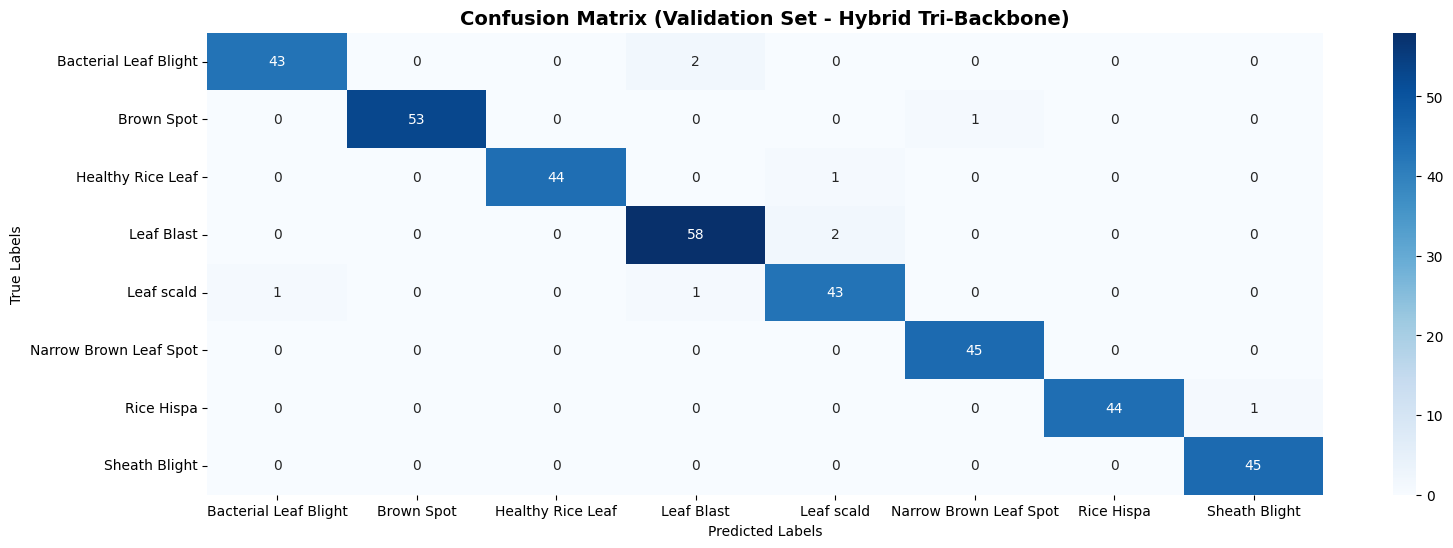

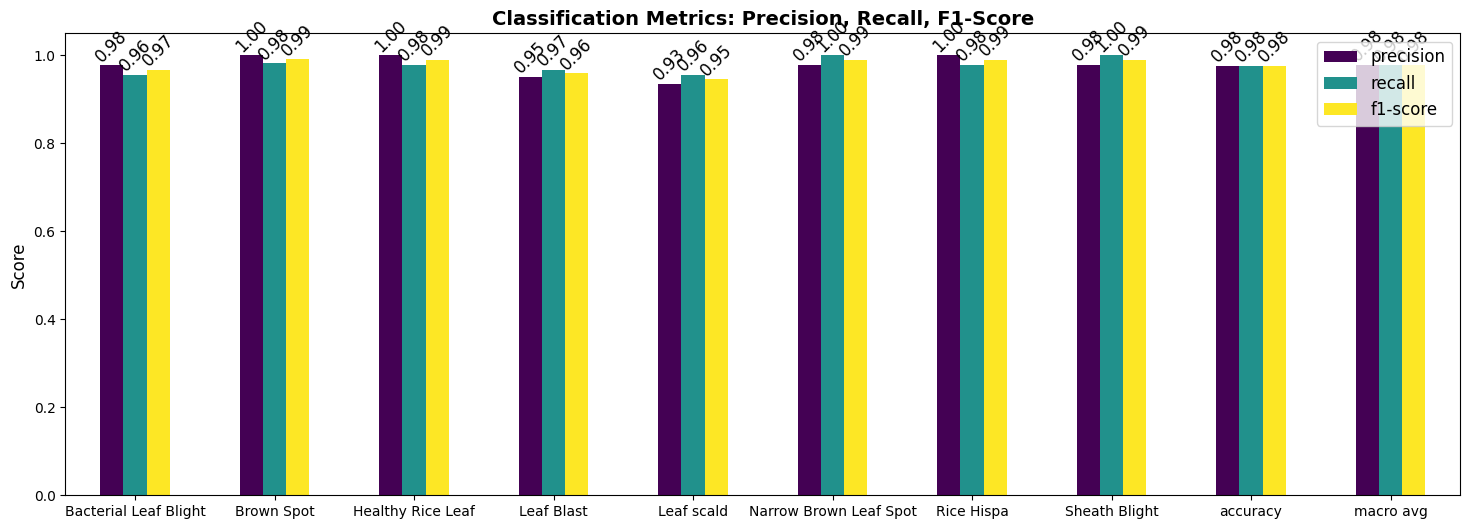


================ Blur (Blurred Image) ================
🔹 Loading best saved hybrid model...


100%|██████████| 12/12 [00:12<00:00,  1.03s/it]



Confusion Matrix:
 [[43  0  0  1  0  0  0  1]
 [ 0 53  0  0  0  1  0  0]
 [ 0  0 45  0  0  0  0  0]
 [ 1  4  0 53  2  0  0  0]
 [ 1  2  0  1 41  0  0  0]
 [ 0  2  0  0  0 43  0  0]
 [ 0  0  0  0  0  0 44  1]
 [ 1  0  0  0  0  0  0 44]]

Classification Report:
                         precision    recall  f1-score   support

 Bacterial Leaf Blight       0.93      0.96      0.95        45
            Brown Spot       0.87      0.98      0.92        54
     Healthy Rice Leaf       1.00      1.00      1.00        45
            Leaf Blast       0.96      0.88      0.92        60
            Leaf scald       0.95      0.91      0.93        45
Narrow Brown Leaf Spot       0.98      0.96      0.97        45
            Rice Hispa       1.00      0.98      0.99        45
         Sheath Blight       0.96      0.98      0.97        45

              accuracy                           0.95       384
             macro avg       0.96      0.96      0.96       384
          weighted avg       0.9

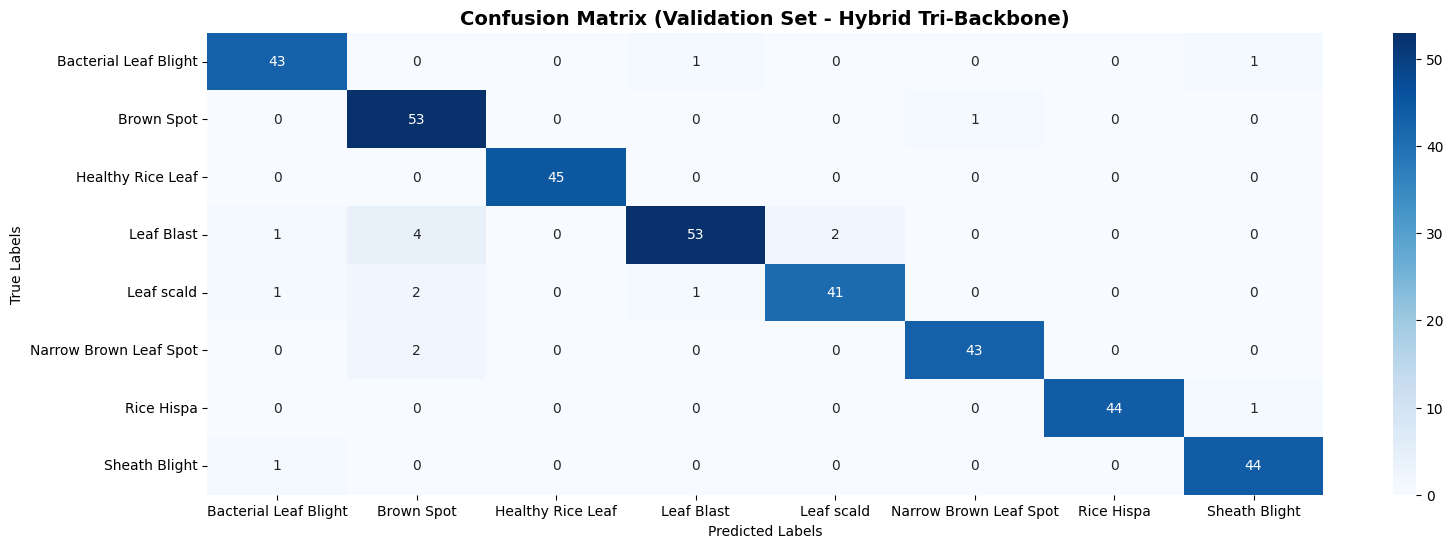

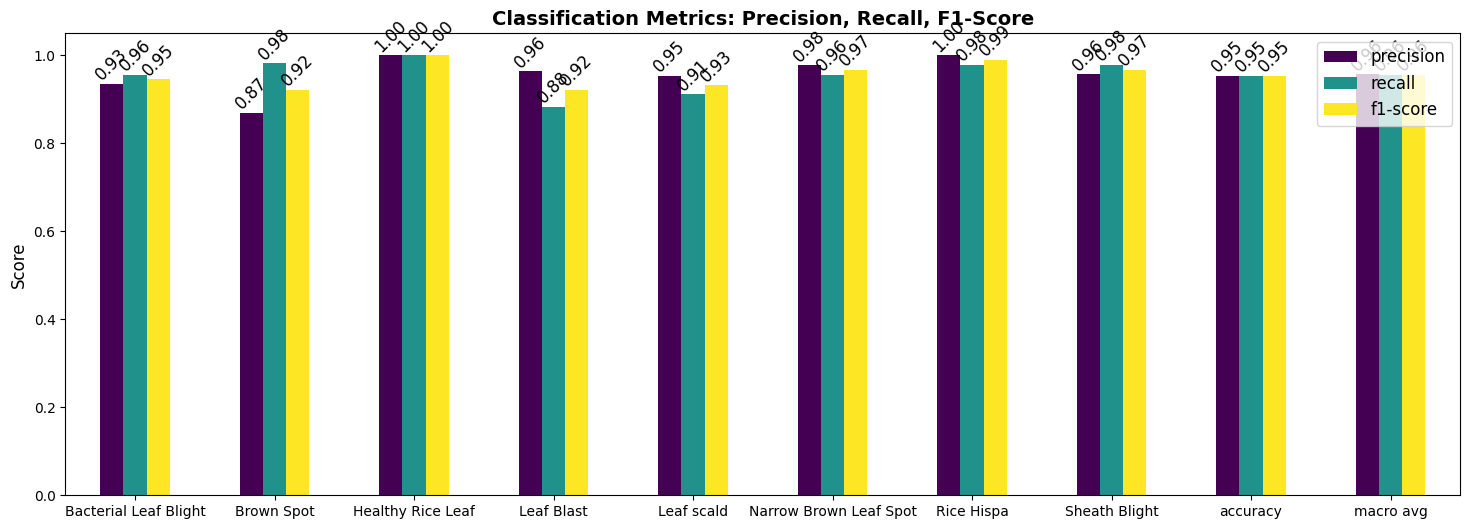


================ Low Brightness (Low Light) ================
🔹 Loading best saved hybrid model...


100%|██████████| 12/12 [00:09<00:00,  1.20it/s]



Confusion Matrix:
 [[43  0  0  2  0  0  0  0]
 [ 0 53  0  0  0  1  0  0]
 [ 0  0 44  0  1  0  0  0]
 [ 1  0  0 57  2  0  0  0]
 [ 1  0  0  1 43  0  0  0]
 [ 0  0  0  0  0 45  0  0]
 [ 0  0  0  0  0  0 44  1]
 [ 0  0  0  0  0  0  0 45]]

Classification Report:
                         precision    recall  f1-score   support

 Bacterial Leaf Blight       0.96      0.96      0.96        45
            Brown Spot       1.00      0.98      0.99        54
     Healthy Rice Leaf       1.00      0.98      0.99        45
            Leaf Blast       0.95      0.95      0.95        60
            Leaf scald       0.93      0.96      0.95        45
Narrow Brown Leaf Spot       0.98      1.00      0.99        45
            Rice Hispa       1.00      0.98      0.99        45
         Sheath Blight       0.98      1.00      0.99        45

              accuracy                           0.97       384
             macro avg       0.97      0.97      0.97       384
          weighted avg       0.9

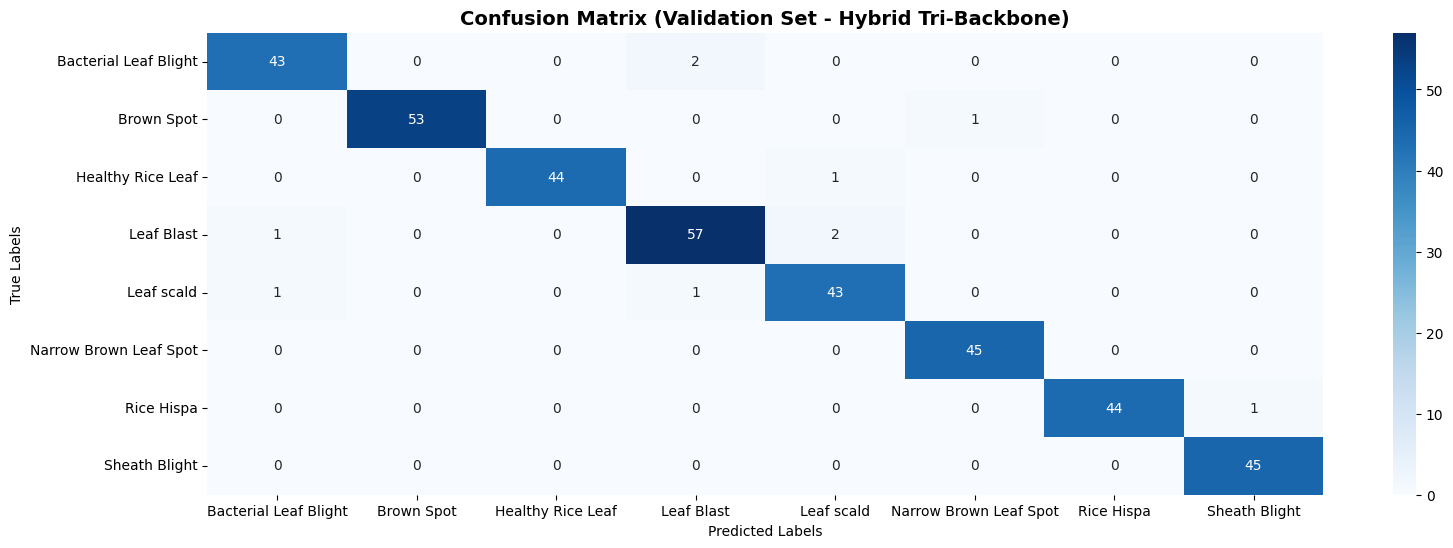

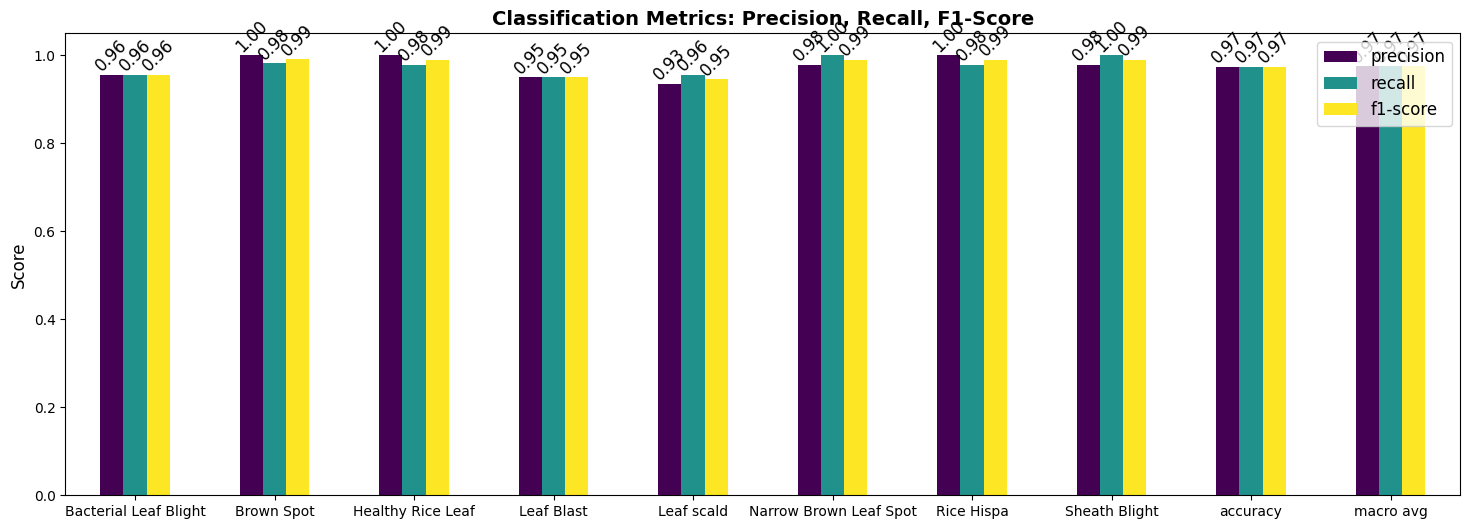


================ Noisy (Low-Quality Camera Simulation) ================
🔹 Loading best saved hybrid model...


100%|██████████| 12/12 [00:10<00:00,  1.19it/s]



Confusion Matrix:
 [[43  0  0  2  0  0  0  0]
 [ 0 52  0  0  0  2  0  0]
 [ 0  0 44  0  1  0  0  0]
 [ 2  0  0 57  1  0  0  0]
 [ 1  1  0  1 42  0  0  0]
 [ 0  1  0  0  0 44  0  0]
 [ 0  0  0  0  0  0 44  1]
 [ 1  0  0  0  0  0  0 44]]

Classification Report:
                         precision    recall  f1-score   support

 Bacterial Leaf Blight       0.91      0.96      0.93        45
            Brown Spot       0.96      0.96      0.96        54
     Healthy Rice Leaf       1.00      0.98      0.99        45
            Leaf Blast       0.95      0.95      0.95        60
            Leaf scald       0.95      0.93      0.94        45
Narrow Brown Leaf Spot       0.96      0.98      0.97        45
            Rice Hispa       1.00      0.98      0.99        45
         Sheath Blight       0.98      0.98      0.98        45

              accuracy                           0.96       384
             macro avg       0.96      0.96      0.96       384
          weighted avg       0.9

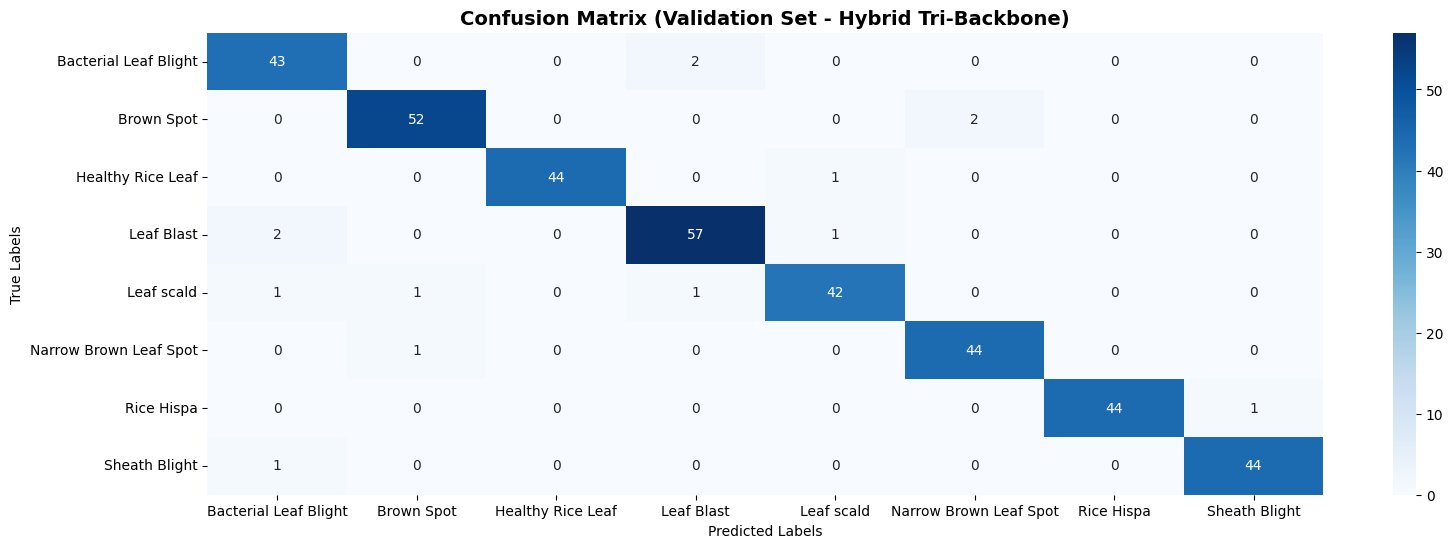

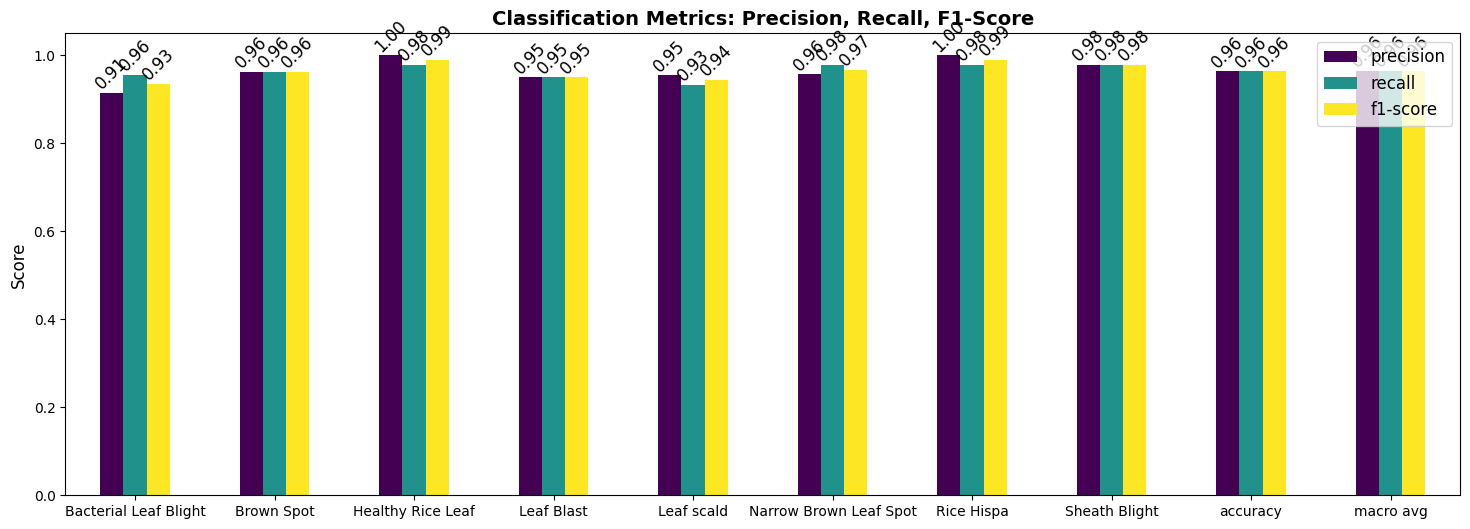

In [51]:
# 4) ROBUSTNESS TESTING (PERTURBATION)
import copy
from torchvision import transforms

perturbations = {
    "Original (No Change)": val_transform,

    "Blur (Blurred Image)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.GaussianBlur(kernel_size=5, sigma=2.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ]),

    "Low Brightness (Low Light)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ]),

    "Noisy (Low-Quality Camera Simulation)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x + 0.05 * torch.randn_like(x)),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ]),
}

for name, tfm in perturbations.items():
    print(f"\n================ {name} ================")
    test_ds = copy.deepcopy(dataloaders['val'].dataset)   # reuse the SAME validation images already in the notebook
    test_ds.transform = tfm                                 # only swap the transform (perturbation)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
    evaluate_model(test_loader)

## 5️ Statistical Significance Testing (McNemar's Test)


In [52]:
# 5) STATISTICAL SIGNIFICANCE TESTING (McNEMAR'S TEST)

!pip install statsmodels -q

from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

fused_preds, aux_eff_preds, true_labels = [], [], []

model.eval()
with torch.no_grad():
    for imgs, labels in dataloaders['val']:
        imgs = imgs.to(device)
        logits, aux_eff_logits, aux_cnx_logits, aux_dav_logits = model(imgs)

        fused_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        aux_eff_preds.extend(torch.argmax(aux_eff_logits, dim=1).cpu().numpy())
        true_labels.extend(labels.numpy())

fused_preds   = np.array(fused_preds)
aux_eff_preds = np.array(aux_eff_preds)
true_labels   = np.array(true_labels)

correct_fused = (fused_preds == true_labels)
correct_aux   = (aux_eff_preds == true_labels)

both_correct  = np.sum(correct_fused & correct_aux)
fused_only    = np.sum(correct_fused & ~correct_aux)
aux_only      = np.sum(~correct_fused & correct_aux)
both_wrong    = np.sum(~correct_fused & ~correct_aux)

table = [[both_correct, fused_only], [aux_only, both_wrong]]
result = mcnemar(table, exact=True)

print("Contingency Table:")
print(f"   Both correct                 : {both_correct}")
print(f"   Only Hybrid correct          : {fused_only}")
print(f"   Only EfficientNet (aux) correct : {aux_only}")
print(f"   Both wrong                   : {both_wrong}\n")
print(f"McNemar's statistic = {result.statistic:.4f}, p-value = {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("✅ p-value < 0.05 -> The improvement from Hybrid fusion is statistically significant.")
else:
    print("⚠️ p-value >= 0.05 -> The difference is not statistically significant on this dataset/sample size.")

Contingency Table:
   Both correct                 : 343
   Only Hybrid correct          : 32
   Only EfficientNet (aux) correct : 2
   Both wrong                   : 7

McNemar's statistic = 2.0000, p-value = 0.0000
✅ p-value < 0.05 -> The improvement from Hybrid fusion is statistically significant.


## 6️ t-SNE Feature Embedding Visualization



Running t-SNE (this may take a little while)...


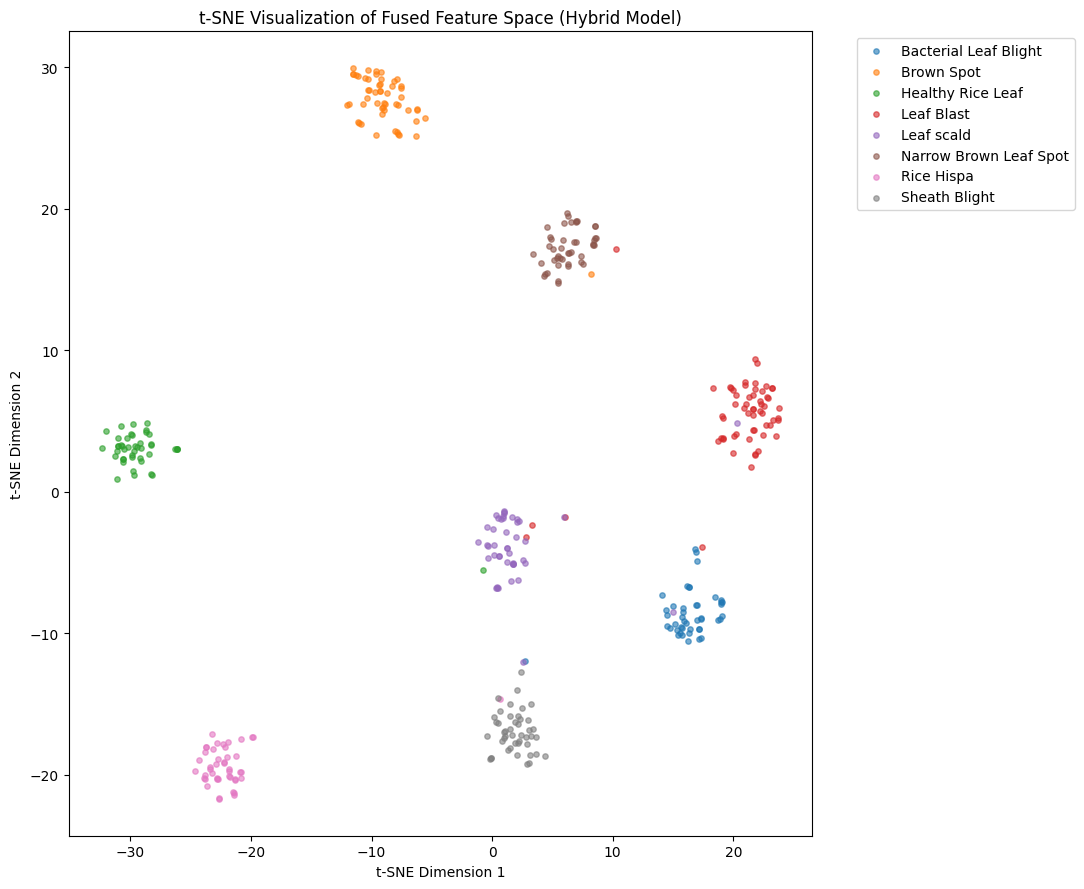


✅ All 6 novelty experiments are complete. These results (accuracy, graphs, tables) can now be added to the thesis's Novelty/Results section.


In [53]:
# 6) t-SNE FEATURE EMBEDDING VISUALIZATION
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

features_list, labels_list = [], []

model.eval()
with torch.no_grad():
    for imgs, labels in dataloaders['val']:
        imgs = imgs.to(device)
        b0p, cnxp, davp = model.forward_backbone_feats(imgs)
        fused_vec, cat_feats = model.fusion_gate(b0p, cnxp, davp)
        combined = torch.cat([fused_vec, cat_feats], dim=1)   # same feature that goes into model.fuser
        features_list.append(combined.cpu().numpy())
        labels_list.extend(labels.numpy())

features_arr = np.concatenate(features_list)
labels_arr   = np.array(labels_list)

print("Running t-SNE (this may take a little while)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
embedded = tsne.fit_transform(features_arr)

plt.figure(figsize=(11, 9))
for i, cls in enumerate(classes):
    idx = labels_arr == i
    plt.scatter(embedded[idx, 0], embedded[idx, 1], label=cls, alpha=0.6, s=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE Visualization of Fused Feature Space (Hybrid Model)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()

print("\n✅ All 6 novelty experiments are complete. These results (accuracy, graphs, tables) can now be added to the thesis's Novelty/Results section.")

Please upload an image...


Saving Narrow_brown_leaf_spot  (16).jpg to Narrow_brown_leaf_spot  (16).jpg

Uploaded: Narrow_brown_leaf_spot  (16).jpg

================ RESULT ================
Leaf is DISEASED
Disease name: Narrow Brown Leaf Spot
Confidence: 75.15%

----- Top 3 Predictions -----
   Narrow Brown Leaf Spot    : 75.15%
   Healthy Rice Leaf         : 4.19%
   Rice Hispa                : 3.97%


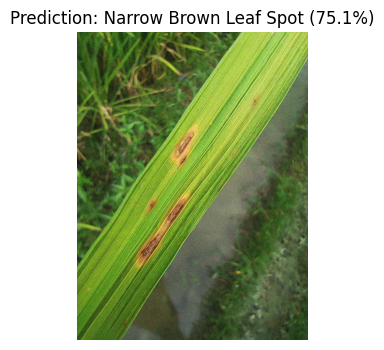

In [56]:
# ================================================================
# SINGLE IMAGE PREDICTION — Upload one image and get the diagnosis
# ================================================================
from google.colab import files
from PIL import Image
import torch
import torch.nn.functional as F

print("Please upload an image...")
uploaded = files.upload()   # select an image file from your computer

image_path = list(uploaded.keys())[0]
print(f"\nUploaded: {image_path}")

# Load and preprocess the image exactly like the validation pipeline
img = Image.open(image_path).convert("RGB")
input_tensor = val_transform(img).unsqueeze(0).to(device)   # add batch dimension

model.eval()
with torch.no_grad():
    outputs = model(input_tensor)
    logits = outputs[0] if isinstance(outputs, tuple) else outputs   # main fused output
    probs = F.softmax(logits, dim=1)[0]
    pred_idx = torch.argmax(probs).item()
    confidence = probs[pred_idx].item() * 100

predicted_class = classes[pred_idx]

print("\n================ RESULT ================")
if "healthy" in predicted_class.lower():
    print(f"Leaf is HEALTHY — Class: {predicted_class}")
else:
    print(f"Leaf is DISEASED")
    print(f"Disease name: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

# Show top-3 predictions for extra context
print("\n----- Top 3 Predictions -----")
top3 = torch.topk(probs, 3)
for i in range(3):
    print(f"   {classes[top3.indices[i]]:25s} : {top3.values[i].item()*100:.2f}%")

# Display the uploaded image
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Prediction: {predicted_class} ({confidence:.1f}%)")
plt.axis("off")
plt.show()

FINAL RESULTS SUMMARY — HYBRID TRI-BACKBONE RICE LEAF DISEASE MODEL

[1] BASELINE vs HYBRID MODEL ACCURACY
   Swin Transformer          : 94.53%
   EfficientNetB0            : 95.83%
   ConvNeXt-Tiny             : 96.09%
   DaViT-Tiny                : 97.14%
   Hybrid (Proposed)         : 97.66%

[2] CROSS-DATASET / EXTERNAL VALIDATION (leak-free, verified via MD5 hash check)
   Original (Validation Set)           : 97.66%
   External (7k Clean, Leak-Free)      : 96.10%
   Accuracy drop on unseen external data     : 1.56%

[3] EFFICIENCY / INFERENCE-TIME BENCHMARK
   Hybrid Tri-Backbone (Proposed)      : 62.32 M params, 92.32 ms/image
   EfficientNetB0                      : 4.02 M params, 52.97 ms/image
   Swin Transformer                    : 27.53 M params, 31.03 ms/image
   ConvNeXt-Tiny                       : 27.83 M params, 7.55 ms/image
   DaViT-Tiny                          : 27.60 M params, 12.91 ms/image

[4] ROBUSTNESS UNDER PERTURBATION
   Original (No Change)      : 98%
 

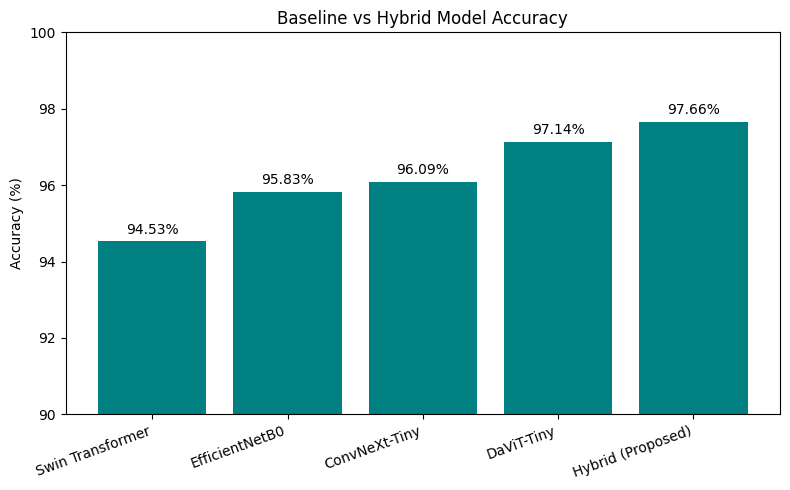

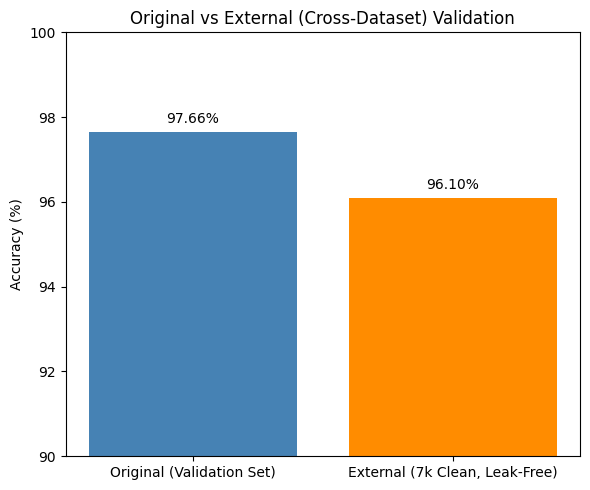

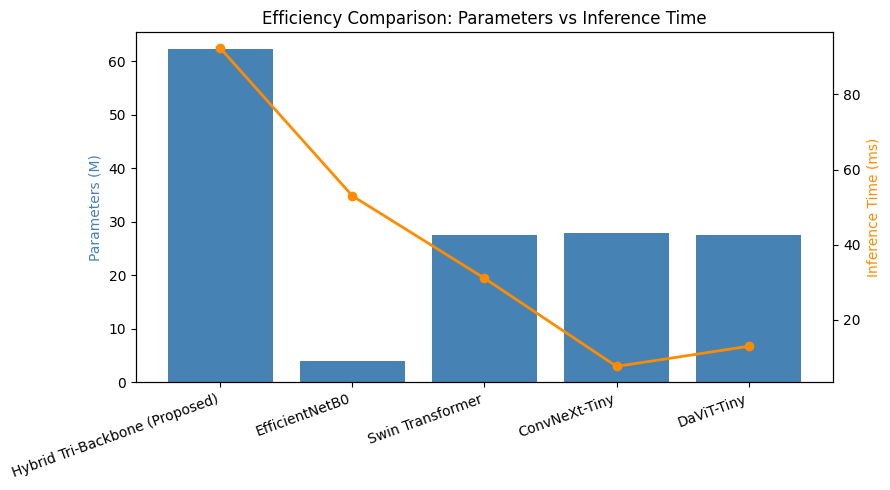

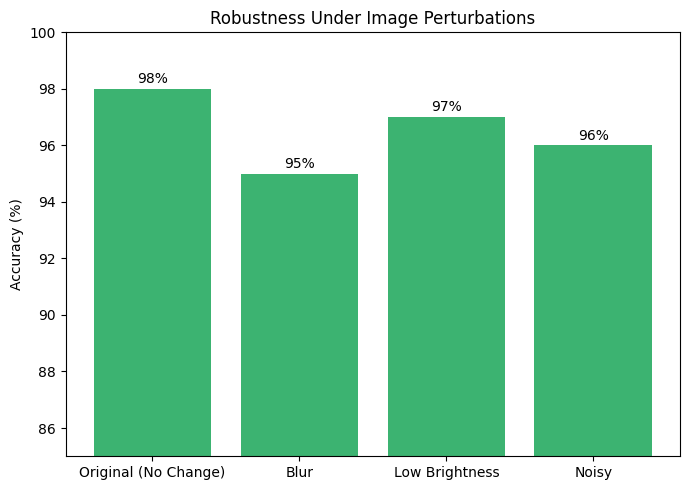


 All results consolidated and saved as PNG files to Google Drive.
 This section is ready to be used directly in the thesis Results/Novelty chapter.


In [58]:
# FINAL SUMMARY — ALL RESULTS CONSOLIDATED
import matplotlib.pyplot as plt
import pandas as pd

# ---------- 1) Baseline vs Hybrid Model Accuracy ----------
model_accuracies = {
    "Swin Transformer":  94.53,
    "EfficientNetB0":    95.83,
    "ConvNeXt-Tiny":     96.09,
    "DaViT-Tiny":        97.14,
    "Hybrid (Proposed)": 97.66,
}

# ---------- 2) Cross-Dataset / External Validation ----------
external_validation = {
    "Original (Validation Set)": 97.66,
    "External (7k Clean, Leak-Free)": 96.10,
}

# ---------- 3) Efficiency Benchmark ----------
efficiency = {
    "Hybrid Tri-Backbone (Proposed)": {"params_M": 62.32, "time_ms": 92.32},
    "EfficientNetB0":                 {"params_M": 4.02,  "time_ms": 52.97},
    "Swin Transformer":               {"params_M": 27.53, "time_ms": 31.03},
    "ConvNeXt-Tiny":                  {"params_M": 27.83, "time_ms": 7.55},
    "DaViT-Tiny":                     {"params_M": 27.60, "time_ms": 12.91},
}

# ---------- 4) Robustness Under Perturbation ----------
robustness = {
    "Original (No Change)": 98,
    "Blur":                 95,
    "Low Brightness":       97,
    "Noisy":                96,
}

# ---------- 5) McNemar's Statistical Test ----------
mcnemar_result = {
    "both_correct": 343,
    "only_hybrid_correct": 32,
    "only_effnet_correct": 2,
    "both_wrong": 7,
    "p_value": 0.0000,
}

# PRINT CONSOLIDATED SUMMARY
print("="*70)
print("FINAL RESULTS SUMMARY — HYBRID TRI-BACKBONE RICE LEAF DISEASE MODEL")
print("="*70)

print("\n[1] BASELINE vs HYBRID MODEL ACCURACY")
for name, acc in model_accuracies.items():
    print(f"   {name:25s} : {acc:.2f}%")

print("\n[2] CROSS-DATASET / EXTERNAL VALIDATION (leak-free, verified via MD5 hash check)")
for name, acc in external_validation.items():
    print(f"   {name:35s} : {acc:.2f}%")
print(f"   Accuracy drop on unseen external data     : {external_validation['Original (Validation Set)'] - external_validation['External (7k Clean, Leak-Free)']:.2f}%")

print("\n[3] EFFICIENCY / INFERENCE-TIME BENCHMARK")
for name, vals in efficiency.items():
    print(f"   {name:35s} : {vals['params_M']:.2f} M params, {vals['time_ms']:.2f} ms/image")

print("\n[4] ROBUSTNESS UNDER PERTURBATION")
for name, acc in robustness.items():
    print(f"   {name:25s} : {acc}%")

print("\n[5] McNEMAR'S STATISTICAL SIGNIFICANCE TEST")
print(f"   Both correct           : {mcnemar_result['both_correct']}")
print(f"   Only Hybrid correct    : {mcnemar_result['only_hybrid_correct']}")
print(f"   Only EfficientNet correct : {mcnemar_result['only_effnet_correct']}")
print(f"   Both wrong             : {mcnemar_result['both_wrong']}")
print(f"   p-value                : {mcnemar_result['p_value']:.4f}  (statistically significant)")

# PLOT 1 — Baseline vs Hybrid Accuracy
plt.figure(figsize=(8,5))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color="teal")
for i, v in enumerate(model_accuracies.values()):
    plt.text(i, v+0.2, f"{v:.2f}%", ha="center")
plt.ylim(90, 100)
plt.ylabel("Accuracy (%)")
plt.title("Baseline vs Hybrid Model Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/final_model_accuracy_comparison.png")
plt.show()

# PLOT 2 — Original vs External Validation Accuracy
plt.figure(figsize=(6,5))
plt.bar(external_validation.keys(), external_validation.values(), color=["steelblue","darkorange"])
for i, v in enumerate(external_validation.values()):
    plt.text(i, v+0.2, f"{v:.2f}%", ha="center")
plt.ylim(90, 100)
plt.ylabel("Accuracy (%)")
plt.title("Original vs External (Cross-Dataset) Validation")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/final_external_validation.png")
plt.show()

# PLOT 3 — Efficiency: Parameters vs Inference Time
eff_df = pd.DataFrame([
    {"Model": name, "Parameters (M)": v["params_M"], "Inference Time (ms)": v["time_ms"]}
    for name, v in efficiency.items()
])
fig, ax1 = plt.subplots(figsize=(9,5))
x = range(len(eff_df))
ax1.bar(x, eff_df["Parameters (M)"], color="steelblue")
ax1.set_ylabel("Parameters (M)", color="steelblue")
ax1.set_xticks(x)
ax1.set_xticklabels(eff_df["Model"], rotation=20, ha="right")
ax2 = ax1.twinx()
ax2.plot(x, eff_df["Inference Time (ms)"], color="darkorange", marker="o", linewidth=2)
ax2.set_ylabel("Inference Time (ms)", color="darkorange")
plt.title("Efficiency Comparison: Parameters vs Inference Time")
fig.tight_layout()
plt.savefig("/content/drive/MyDrive/final_efficiency_comparison.png")
plt.show()

# PLOT 4 — Robustness Under Perturbation
plt.figure(figsize=(7,5))
plt.bar(robustness.keys(), robustness.values(), color="mediumseagreen")
for i, v in enumerate(robustness.values()):
    plt.text(i, v+0.2, f"{v}%", ha="center")
plt.ylim(85, 100)
plt.ylabel("Accuracy (%)")
plt.title("Robustness Under Image Perturbations")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/final_robustness.png")
plt.show()

print("\n All results consolidated and saved as PNG files to Google Drive.")
print(" This section is ready to be used directly in the thesis Results/Novelty chapter.")